In [41]:
import json
import gurobipy as gp
from gurobipy import GRB
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from scipy.special import stirling2
import math
from copy import copy
import scipy
import tqdm
import pandas as pd
from mosek.fusion import *
import mosek.fusion.pythonic
from SDP_interaction_inference.simulation import gillespie_birth_death

In [2]:
status_codes = {
    1: 'LOADED',
    2: 'OPTIMAL',
    3: 'INFEASIBLE',
    4: 'INF_OR_UNBD',
    5: 'UNBOUNDED',
    6: 'CUTOFF',
    7: 'ITERATION_LIMIT',
    8: 'NODE_LIMIT',
    9: 'TIME_LIMIT',
    10: 'SOLUTION_LIMIT',
    11: 'INTERRUPTED',
    12: 'NUMERIC',
    13: 'SUBOPTIMAL',
    14: 'INPROGRESS',
    15: 'USER_OBJ_LIMIT'
}

In [3]:
rng = np.random.default_rng(643)

# SDP Minimal Working Example

# Multivariate utils

In [13]:
def compute_order(alpha):
    '''Sum of elements of a power.'''
    order = 0
    for alpha_i in alpha:
        order += alpha_i
    return order

def compute_Nd(S, d):
    '''Number of moments of order <= d (S species)'''
    Nd = math.factorial(S + d) // (math.factorial(d) * math.factorial(S))
    return Nd

def compute_powers(S, d):
    '''Compute the Nd powers of order <= d (S species)'''

    # all powers
    powers = [[0 for s in range(S)]]

    # powers of order d = 0
    powers_prev = [[0 for s in range(S)]]

    # for order d = 1, ..., d
    for order in range(1, d + 1):

        # store powers of order d
        powers_current = []

        # for each power of order d - 1
        for alpha in powers_prev:

            # for each index
            for i in range(S):

                # add 1 to power at index
                alpha_new = copy(alpha)
                alpha_new[i] += 1

                # store (avoid repeats)
                if alpha_new not in powers_current:
                    powers_current.append(alpha_new)

        # update d - 1 powers
        powers += powers_current

        # update overall powers
        powers_prev = powers_current

    return powers

def add_powers(*powers, S):
    '''Add powers (lists) of size S.'''
    plus = [0 for i in range(S)]
    for i in range(S):
        for power in powers:
            plus[i] += power[i]
    return plus

def falling_factorial(n, k):
    '''FF(n,k) = n(n-1) ... (n - k + 1).'''
    val = 1
    for i in range(k):
        val *= (n - i)
    return val

def binomial_moment(n, p, l):
    '''For X ~ Bin(n, p) compute E[X^l].'''
    val = 0
    for k in range(l + 1):
        val += falling_factorial(n, k) * stirling2(l, k) * p**k
    return val

# Bootstrap

In [14]:
def bootstrap(sample, d, resamples=None, confidence=0.95):
    '''
    Compute confidence intervals on the moments of a sample of count pairs, use
    resamples number of bootstrap resamples (default to sample size) and estimate
    moments up to order d.

    Args:
        sample: list of tuples (x1, x2) of integer counts per cell
        d: maximum moment order to estimate
        resamples: integer number of bootstrap resamples to use

    Returns:
        (2 x Nd) numpy array of CI bounds on each Nd moment of order <= d
    '''

    # get sample size
    n = len(sample)

    # get bootstrap size: default to sample size
    if resamples is None:
        resamples = n

    # helpful values
    powers = compute_powers(S=2, d=d)
    Nd = compute_Nd(S=2, d=d)

    # initialize random generator
    rng = np.random.default_rng()

    # convert string to tuple if neccessary (pandas reading csv to string)
    #if type(sample[0]) == str:
    #    sample = [literal_eval(count_pair) for count_pair in sample]

    # separate sample pairs
    x1_sample = [x[0] for x in sample]
    x2_sample = [x[1] for x in sample]

    # convert sample to n x 2 array
    sample = np.array([x1_sample, x2_sample]).T

    # bootstrap to N x n x 2 array
    boot = rng.choice(sample, size=(resamples, n))

    # split into 2 N x n arrays
    x1_boot = boot[:, :, 0]
    x2_boot = boot[:, :, 1]

    # estimate
    moment_bounds = np.zeros((2, Nd))
    for i, alpha in enumerate(powers):

        # raise boot to powers
        x1_boot_alpha = x1_boot**alpha[0]
        x2_boot_alpha = x2_boot**alpha[1]

        # multiply (N x n)
        boot_alpha = x1_boot_alpha * x2_boot_alpha

        # mean over sample axis (N x 1)
        moment_estimates = np.mean(boot_alpha, axis=1)

        # quantile over boot axis (2 x 1)
        alpha = 1 - confidence
        moment_interval = np.quantile(moment_estimates, [(alpha / 2), 1 - (alpha / 2)])

        # store
        moment_bounds[:, i] = moment_interval

    return moment_bounds

# Downsampling

In [15]:
def downsample_data(sample, mean_capture):

    n = len(sample)

    b = (1 / mean_capture) - 1

    # capture efficiency
    if b == 0:
        beta = np.ones(n)
    else:
        beta = rng.beta(1, b, size=1000)

    # split
    x1_sample = [x[0] for x in sample]
    x2_sample = [x[1] for x in sample]

    # downsample
    x1_downsample = rng.binomial(x1_sample, beta).tolist()
    x2_downsample = rng.binomial(x2_sample, beta).tolist()

    # combine
    downsample = list(zip(x1_downsample, x2_downsample))

    return downsample, beta

# Moment equations

In [16]:
def compute_A(alpha, reactions, vrs, db, R, S, d):
    '''
    Moment equation coefficient matrix
    NOTE: must have order of alpha <= d

    Args:
        alpha: moment order for equation (d/dt mu^alpha = 0)
        reactions: list of strings detailing a_r(x) for each reaction r
        vrs: list of lists detailing v_r for each reaction r
        db: largest order a_r(x)
        R: number of reactions
        S: number of species
        d: maximum moment order used (must be >= order(alpha) + db - 1)

    Returns:
        A: (R, Nd) matrix of coefficients
    '''

    if compute_order(alpha) > d - db + 1:
        raise NotImplementedError(f"Maximum moment order {d} too small for moment equation of alpha = {alpha}: involves moments of higher order.")

    xs = sp.symbols([f'x{i}' for i in range(S)])

    # reaction propensity polynomials
    # props = [eval(str_ar) for str_ar in reactions]
    props = [sp.parse_expr(str_ar, {'xs': xs}) for str_ar in reactions]

    # number of moments of order <= d
    Nd = compute_Nd(S, d)

    # get powers of order <= d
    powers = compute_powers(S, d)

    # setup matrix
    A = np.zeros((R, Nd))

    for r, prop in enumerate(props):

        # expand b(x) * ((x + v_r)**alpha - x**alpha)
        term_1 = 1
        term_2 = 1
        for i in range(S):
            term_1 = term_1 * (xs[i] + vrs[r][i])**alpha[i]
            term_2 = term_2 * xs[i]**alpha[i]
        poly = sp.Poly(prop * (term_1 - term_2), xs)

        # loop over terms
        for xs_power, coeff in zip(poly.monoms(), poly.coeffs()):

            # get matrix index
            col = powers.index(list(xs_power))

            # store
            A[r, col] = coeff

    return A

# B Capture matrix

In [17]:
def compute_B(beta, S, U, d):
    '''
    Capture efficiency moment scaling matrix

    Args:
        beta: per cell capture efficiency sample
        S: number of species
        U: unobserved species indices
        d: maximum moment order used

    Returns:
        B: (Nd, Nd) matrix of coefficients
    '''

    # number of moments of order <= d
    Nd = compute_Nd(S, d)

    # compute powers of order <= d
    powers = compute_powers(S, d)

    # compute beta moments of order <= d
    y_beta = np.zeros(d + 1)
    for l in range(d + 1):
        y_beta[l] = np.mean(beta**l)

    # setup matrix
    B = np.zeros((Nd, Nd))

    p = sp.Symbol('p')
    xs = sp.symbols([f'x{i}' for i in range(S)])

    # for each moment power
    for row, alpha in enumerate(powers):

        # setup polynomail
        poly_alpha = 1

        # for each species
        for i in range(S):

            # unobserved: no capture efficiency
            if i in U:
                moment = xs[i]**alpha[i]

            # observed: compute moment expression for E[Xi^alphai] in xi
            else:
                moment = binomial_moment(xs[i], p, alpha[i])
            
            poly = sp.Poly(moment, p, xs[i])

            # multiply
            poly_alpha = poly_alpha * poly

        # loop over terms
        for (beta_power, *xs_power), coeff in zip(poly_alpha.monoms(), poly_alpha.coeffs()):

            # get matrix index
            col = powers.index(xs_power)

            B[row, col] += coeff * y_beta[beta_power]

    return B

# Moment matrices

In [18]:
def construct_M_s(y, s, S, d):
    '''Moment matrix variable constructor (s).'''
    if s == 0:
        D = math.floor(d / 2)
    else:
        D = math.floor((d - 1) / 2)
    powers_D = compute_powers(S, D)
    powers_d = compute_powers(S, d)
    ND = compute_Nd(S, D)
    M_s = [[0 for j in range(ND)] for i in range(ND)]
    e_s = [1 if i == (s - 1) else 0 for i in range(S)]
    for alpha_index, alpha in enumerate(powers_D):
        for beta_index, beta in enumerate(powers_D):
            plus = add_powers(alpha, beta, e_s, S=S)
            plus_index = powers_d.index(plus)
            M_s[alpha_index][beta_index] = y[plus_index].item()
    M_s = gp.MVar.fromlist(M_s)
    return M_s

In [19]:
def construct_M_s_string(y, s, S, d):
    '''Moment matrix variable constructor (s).'''
    if s == 0:
        D = math.floor(d / 2)
    else:
        D = math.floor((d - 1) / 2)
    powers_D = compute_powers(S, D)
    powers_d = compute_powers(S, d)
    ND = compute_Nd(S, D)
    M_s = [[0 for j in range(ND)] for i in range(ND)]
    e_s = [1 if i == (s - 1) else 0 for i in range(S)]
    for alpha_index, alpha in enumerate(powers_D):
        for beta_index, beta in enumerate(powers_D):
            plus = add_powers(alpha, beta, e_s, S=S)
            plus_index = powers_d.index(plus)
            M_s[alpha_index][beta_index] = f"y_{plus}"
    M_s = np.array(M_s)
    return M_s

In [11]:
s = 0
S = 2
d = 3
construct_M_s_string(_, s, S, d)

array([['y_[0, 0]', 'y_[1, 0]', 'y_[0, 1]'],
       ['y_[1, 0]', 'y_[2, 0]', 'y_[1, 1]'],
       ['y_[0, 1]', 'y_[1, 1]', 'y_[0, 2]']], dtype='<U8')

In [12]:
compute_Nd(S=1, d=1)

2

# MOSEK model

In [20]:
def MOSEK_compute_feasible_correlation(d, y):
    '''Compute correlation value at feasible point.'''

    # find indices of moments
    powers = compute_powers(S, d)
    i_xy = powers.index([1, 1])
    i_x  = powers.index([1, 0])
    i_y  = powers.index([0, 1])
    i_x2 = powers.index([2, 0])
    i_y2 = powers.index([0, 2])

    # collect moment values
    E_xy = y[i_xy]
    E_x  = y[i_x]
    E_y  = y[i_y]
    E_x2 = y[i_x2]
    E_y2 = y[i_y2]

    # compute correlation
    correlation = (E_xy - E_x*E_y) / (np.sqrt(E_x2 - E_x**2) * np.sqrt(E_y2 - E_y**2))

    return float(correlation)

In [21]:
def MOSEK_construct_M_s(y, s, S, d):
    '''Moment matrix variable constructor (s).'''
    if s == 0:
        D = math.floor(d / 2)
    else:
        D = math.floor((d - 1) / 2)
    powers_D = compute_powers(S, D)
    powers_d = compute_powers(S, d)
    ND = compute_Nd(S, D)
    M_s = [] # [[0 for j in range(ND)] for i in range(ND)]
    e_s = [1 if i == (s - 1) else 0 for i in range(S)]
    for alpha_index, alpha in enumerate(powers_D):
        for beta_index, beta in enumerate(powers_D):
            plus = add_powers(alpha, beta, e_s, S=S)
            plus_index = powers_d.index(plus)
            M_s.append(y[plus_index]) # M_s[alpha_index][beta_index] = y[plus_index]
    M_s = Expr.reshape(Expr.vstack(M_s), [ND, ND]) # M_s = gp.MVar.fromlist(M_s)
    return M_s

## Correlation interval via random optimization

In [22]:
def data_correlation_bootstrap(sample, confidence=0.95, resamples=1000, printing=True):

    # sample size
    n = sample.shape[0]

    # bootstrap to N x n x 2 array
    boot = rng.choice(sample, size=(resamples, n))

    # compute correlations
    estimates = np.zeros(resamples)
    for i in range(resamples):

        test = scipy.stats.pearsonr(boot[i, :, 0], boot[i, :, 1])
        estimates[i] = test.statistic

    # take quantiles
    alpha = 1 - confidence
    interval = np.quantile(estimates, [(alpha / 2), 1 - (alpha / 2)])

    # point estimate
    corr = scipy.stats.pearsonr(sample[:, 0], sample[:, 1]).statistic

    if printing:
        print(f"Correlation statistic {corr} \n{int(confidence*100)}% Confidence Interval ({interval[0]}, {interval[1]})")

    return interval

In [23]:
def MOSEK_corr(OB_bounds, beta, d_bd, d_sd, obj=None, N=10):

    # compute the highest order moment required
    d = max(d_bd, d_sd)

    # helpful values
    S = 2
    U = []
    Nd = compute_Nd(S, d)
    Nbd = compute_Nd(S, d_bd)

    with Model('MOSEK-SDP') as md: 

        # variables
        y = md.variable('y', Nd, Domain.greaterThan(0.))

        # variable dict
        variables = {
            'y': y
        }

        # moment matrices
        for s in range(S + 1):

            # restrict to d_sd
            M_s = MOSEK_construct_M_s(y, s, S, d_sd)
            variables[f'M_{s}'] = M_s

            # PSD
            md.constraint(f'M_{s}_PSD', M_s == Domain.inPSDCone())

        # moment bounds

        # get CI bounds on OB moments (up to order d_bd)
        y_lb = OB_bounds[0, :Nbd]
        y_ub = OB_bounds[1, :Nbd]

        # B scaling matrix
        B = compute_B(beta, S, U, d_bd)

        # moment bounds
        md.constraint('y_UB', B @ y[:Nbd] <= y_ub)
        md.constraint('y_LB', B @ y[:Nbd] >= y_lb)

        # fixed moment
        md.constraint('y0', y[0] == 1)

        # collect correlations
        correlations = []

        # collect feasible moment vectors
        moments = []

        # objective
        if obj is None:
            md.objective(0)
            md.solve()
            corr = MOSEK_compute_feasible_correlation(d, y.level())
            correlations.append(corr)
            moments.append(y.level())
        elif obj == "index":
            for i in range(Nd): # sometimes becomes infeasible when setting objective to moments that are only semidefinite bounded???
                try:
                    md.objective(ObjectiveSense.Minimize, y[i])
                    md.solve()
                    corr = MOSEK_compute_feasible_correlation(d, y.level())
                    correlations.append(corr)
                    moments.append(y.level())
                except SolutionError:
                    pass # correlation.append(None)
                try:
                    md.objective(ObjectiveSense.Maximize, y[i])
                    md.solve()
                    corr = MOSEK_compute_feasible_correlation(d, y.level())
                    correlations.append(corr)
                    moments.append(y.level())
                except:
                    pass # correlations.append(None)
        elif obj == "random":
            for i in range(N):
                try:
                    c = np.zeros(Nd) # becomes infeasible when objective includes moments that are only semidefinite bounded???
                    c[:Nbd] = rng.uniform(-1, 1, size=Nbd)
                    md.objective(ObjectiveSense.Minimize, y.T @ c)
                    md.solve()
                    corr = MOSEK_compute_feasible_correlation(d, y.level())
                    correlations.append(corr)
                    moments.append(y.level())
                except SolutionError:
                    pass # correlations.append(None)
        elif obj == "random_2":
            N2 = compute_Nd(2, 2)
            for i in range(N):
                #try:
                c = np.zeros(Nd)
                c[:N2] = rng.uniform(-1, 1, size=N2) # only optimize over moments in correlation function
                md.objective(ObjectiveSense.Minimize, y.T @ c)
                md.solve()
                corr = MOSEK_compute_feasible_correlation(d, y.level())
                correlations.append(corr)
                moments.append(y.level())
                #except SolutionError:
                #    pass # correlations.append(None)

    return correlations, moments

## Test

In [186]:
# settings
k_tx = 2
k_deg = 1
k_reg = 1

n = 1000
N = 1000

# sample
params = {
    'k_tx_1': k_tx,
    'k_tx_2': k_tx,
    'k_deg_1': k_deg,
    'k_deg_2': k_deg,
    'k_reg': k_reg
}
sample = gillespie_birth_death(params, n)

# downsample
mean_capture = 1
downsample, beta = downsample_data(sample, mean_capture)

# mean expression level
print(f"Mean expression {np.mean(downsample)}")

# order
d_boot = 6

# bootstrap
OB_bounds = bootstrap(downsample, d_boot, N)

Mean expression 1.108


In [187]:
# data correlation
interval = data_correlation_bootstrap(np.array(sample))

Correlation statistic -0.26948111737504427 
95% Confidence Interval (-0.31359476492931465, -0.22286092936130458)


In [188]:
# single feasible point
correlation, moment = MOSEK_corr(OB_bounds, beta, 3, 3)
correlation

[-0.28725075577765596]

# (Wrong) Hit and Run

In [24]:
def compute_M_s_value(y, s, S, d):
    '''Moment matrix value (s).'''
    if s == 0:
        D = math.floor(d / 2)
    else:
        D = math.floor((d - 1) / 2)
    powers_D = compute_powers(S, D)
    powers_d = compute_powers(S, d)
    ND = compute_Nd(S, D)
    M_s = np.zeros((ND, ND))
    e_s = [1 if i == (s - 1) else 0 for i in range(S)]
    for alpha_index, alpha in enumerate(powers_D):
        for beta_index, beta in enumerate(powers_D):
            plus = add_powers(alpha, beta, e_s, S=S)
            plus_index = powers_d.index(plus)
            M_s[alpha_index, beta_index] = y[plus_index]
    return M_s

In [25]:
def MOSEK_feasible_points(OB_bounds, beta, d_bd, d_sd, method="single", N=100):

    # compute the highest order moment required
    d = max(d_bd, d_sd)

    # helpful values
    S = 2
    U = []
    Nd = compute_Nd(S, d)
    Nbd = compute_Nd(S, d_bd)

    with Model('MOSEK-SDP') as md: 

        # variables
        y = md.variable('y', Nd, Domain.greaterThan(0.))

        # variable dict
        variables = {
            'y': y
        }

        # moment matrices
        for s in range(S + 1):

            # restrict to d_sd
            M_s = MOSEK_construct_M_s(y, s, S, d_sd)
            variables[f'M_{s}'] = M_s

            # PSD
            md.constraint(f'M_{s}_PSD', M_s == Domain.inPSDCone())

        # moment bounds

        # get CI bounds on OB moments (up to order d_bd)
        y_lb = OB_bounds[0, :Nbd]
        y_ub = OB_bounds[1, :Nbd]

        # B scaling matrix
        B = compute_B(beta, S, U, d_bd)

        # moment bounds
        md.constraint('y_UB', B @ y[:Nbd] <= y_ub)
        md.constraint('y_LB', B @ y[:Nbd] >= y_lb)

        # fixed moment
        md.constraint('y0', y[0] == 1)

        # find feasible point(s)
        if method == "single":

            # single feasible point
            md.objective(0)
            md.solve()
            y_feas = y.level()

        elif method == "index":

            # feasible point for min and max of each variable (index of y)
            y_feas = []
            for i in range(Nd):
                
                # minimize
                try:
                    md.objective(ObjectiveSense.Minimize, y[i])
                    md.solve()
                    y_feas.append(y.level())
                except SolutionError:
                    print("SE")
                    pass

                # maximize
                try:
                    md.objective(ObjectiveSense.Maximize, y[i])
                    md.solve()
                    y_feas.append(y.level())
                except SolutionError:
                    print("SE")
                    pass

        elif method == "random":

            # optimize random linear objectives
            y_feas = []

            for i in range(N):
                try:
                    c = np.zeros(Nd)
                    c[:Nbd] = rng.uniform(-1, 1, size=Nbd)
                    md.objective(ObjectiveSense.Minimize, y.T @ c)
                    md.solve()
                    y_feas.append(y.level())
                except SolutionError:
                    print("SE")
                    pass
        
        elif obj == "random_2":

            # optimize random linear objectives: only including order <2 moments
            y_feas = []

            N2 = compute_Nd(2, 2)
            for i in range(N):
                try:
                    c = np.zeros(Nd)
                    c[:N2] = rng.uniform(-1, 1, size=N2) # only optimize over moments in correlation function
                    md.objective(ObjectiveSense.Minimize, y.T @ c)
                    md.solve()
                    y_feas.append(y.level())
                except SolutionError:
                    print("SE")
                    pass

    return y_feas

In [26]:
def hit_and_run(OB_bounds, beta, d_bd, d_sd, y_feas, N=1000, method="endpoint", M=10, eps=10**-6):

    # compute the highest order moment required
    d = max(d_bd, d_sd)

    # helpful values
    S = 2
    U = []
    Nd = compute_Nd(S, d)
    Nbd = compute_Nd(S, d_bd)
    y_lb = OB_bounds[0, :Nbd]
    y_ub = OB_bounds[1, :Nbd]
    B = compute_B(beta, S, U, d_bd)

    # record correlations
    correlations = []

    # record numerical errors: err (tmin > 0 or tmax < 0), eps (|tmin - tmax| < eps)
    t_int_err = 0
    t_int_eps = 0

    # repeats
    for n in range(N):

        # sample random direction (uniform on sphere)
        v = rng.multivariate_normal(np.zeros(Nd), np.diag(np.ones(Nd)))
        v = v / np.linalg.norm(v)

        # ignore 1st dimension as fixed y[0] = 1
        v[0] = 0

        # linear t range: y_lb < B (y_0 + tv) < l_ub
        t_linear = np.zeros((Nd, 2))
        t_linear[0, :] = [-np.inf, np.inf]
        #t_linear_M = np.zeros((Nd, 2))
        #t_linear_M[0, :] = [-np.inf, np.inf]
        l = y_lb - B @ y_feas
        u = y_ub - B @ y_feas
        Bv = B @ v
        # l < t Bv < u
        for i in range(1, Nd):
            if Bv[i] > 0:
                t_linear[i, :] = [l[i] / Bv[i], u[i] / Bv[i]]
            else:
                t_linear[i, :] = [u[i] / Bv[i], l[i] / Bv[i]]

        #t_linear_M[1:, 0] = l[1:] / Bv[1:]
        #t_linear_M[1:, 1] = u[1:] / Bv[1:]
        #t_linear_M.sort(axis=1)

        #print(t_linear)
        #print(t_linear_M)

        # semidefinite t range
        t_semi = np.zeros((S + 1, 2))

        # for each matrix
        for s in range(S + 1):

            # generalized eigenvalues
            C = compute_M_s_value(y_feas, s, S, d)
            D = compute_M_s_value(v, s, S, d)
            evals, _ = scipy.linalg.eig(C, -D)
            mu = np.array([np.real(ev) for ev in evals])

            # mu > 0 (lam < 0)
            mu_pos = mu[mu > 0]
            if mu_pos.size == 0:
                t_semi[s, 0] = -np.inf
            else:
                t_semi[s, 0] = -1 / np.max(mu_pos)

            # mu < 0 (lam > 0)
            mu_neg = mu[mu < 0]
            if mu_neg.size == 0:
                t_semi[s, 1] = np.inf
            else:
                t_semi[s, 1] = -1 / np.min(mu_neg)

        # intersect all t intervals
        t_min = max(np.max(t_linear[:, 0]), np.max(t_semi[:, 0]))
        t_max = min(np.min(t_linear[:, 1]), np.min(t_semi[:, 1]))

        # if width of t interval too small / numerical error: skip
        if (t_min > 0 or t_max < 0) and np.abs(t_max - t_min) < eps:
            t_int_err += 1
            t_int_eps += 1
            continue
        elif (t_min > 0 or t_max < 0):
            t_int_err += 1
            continue
        elif np.abs(t_max - t_min) < eps:
            t_int_eps += 1
            continue
            
        if method == "endpoint":

            # compute correlations at endpoints of t interval
            correlations.append(MOSEK_compute_feasible_correlation(d, y_feas + t_min * v))
            correlations.append(MOSEK_compute_feasible_correlation(d, y_feas + t_max * v))

        elif method == "sample":

            # sample M points uniformly along t interval
            try:
                ts = rng.uniform(t_min, t_max, size=M)
                for t in ts:
                    correlations.append(MOSEK_compute_feasible_correlation(d, y_feas + t * v))
            except ValueError:
                print(t_min, t_max)

    return correlations, t_int_err, t_int_eps

## Running

In [192]:
# settings
k_tx = 2
k_deg = 1
k_reg = 1

n = 1000
N = 1000

# sample
params = {
    'k_tx_1': k_tx,
    'k_tx_2': k_tx,
    'k_deg_1': k_deg,
    'k_deg_2': k_deg,
    'k_reg': k_reg
}
sample = gillespie_birth_death(params, n)

# downsample
mean_capture = 1
downsample, beta = downsample_data(sample, mean_capture)

# mean expression level
print(f"Mean expression {np.mean(downsample)}")

# order
d_boot = 6

# bootstrap
OB_bounds = bootstrap(downsample, d_boot, N)

# data correlation
interval = data_correlation_bootstrap(np.array(sample))

Mean expression 1.116
Correlation statistic -0.287461605966161 
95% Confidence Interval (-0.33686759264073785, -0.2393238055946908)


In [193]:
# settings
d_bd = 3
d_sd = 3
d = max(d_bd, d_sd)

# single feasible point
y_feas = MOSEK_feasible_points(OB_bounds, beta, d_bd, d_sd, method="single")

# correlation
corr_feas = MOSEK_compute_feasible_correlation(d, y_feas)
print(corr_feas)

# hit and run methods: match size (endpoint 2 per, sample M per)
N = 2000
M = 10
Ne = N // 2
Ns = N // M
correlations_endpoint, err_end, eps_end = hit_and_run(OB_bounds, beta, d_bd, d_sd, y_feas, N=Ne, method="endpoint")
correlations_sample, err_sam, eps_sam = hit_and_run(OB_bounds, beta, d_bd, d_sd, y_feas, N=Ns, method="sample", M=M)

-0.29903314476141885


In [194]:
# no t intervals have errors or are too small
err_end, eps_end, err_sam, eps_sam

(0, 0, 0, 0)

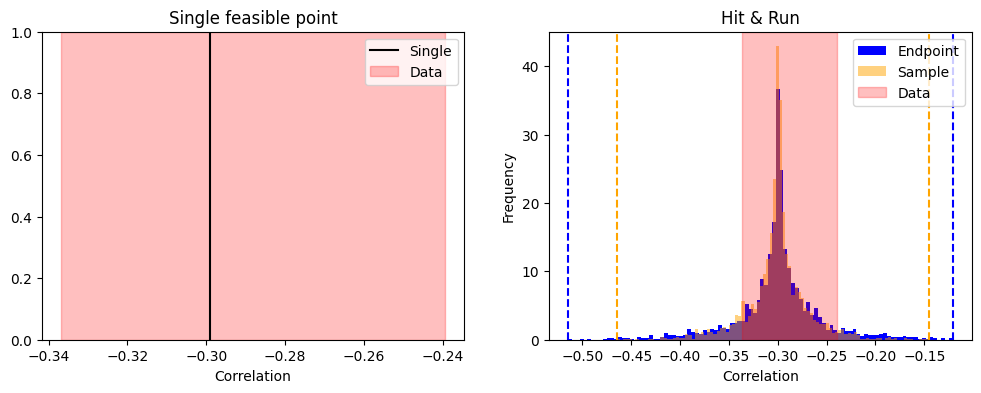

In [196]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].axvline(corr_feas, color="black", label="Single")
axs[0].axvspan(interval[0], interval[1], alpha=0.25, color="red", label="Data")
axs[0].set_title("Single feasible point")
axs[0].set_xlabel("Correlation")
axs[0].legend()
axs[1].hist(correlations_endpoint, color="blue", bins=100, density=True, label="Endpoint")
axs[1].axvline(min(correlations_endpoint), linestyle="--", color="blue")
axs[1].axvline(max(correlations_endpoint), linestyle="--", color="blue")
axs[1].hist(correlations_sample, color="orange", bins=100, alpha=0.5, density=True, label="Sample")
axs[1].axvline(min(correlations_sample), linestyle="--", color="orange")
axs[1].axvline(max(correlations_sample), linestyle="--", color="orange")
axs[1].axvspan(interval[0], interval[1], alpha=0.25, color="red", label="Data")
axs[1].set_title("Hit & Run")
axs[1].set_xlabel("Correlation")
axs[1].set_ylabel("Frequency")
axs[1].legend()
plt.show()

In [197]:
# settings
d_bd = 3
d_sd = 3
d = max(d_bd, d_sd)

# index feasible points
y_feas_list = MOSEK_feasible_points(OB_bounds, beta, d_bd, d_sd, method="index")

# correlation
corr_feas = []
for y_feas in y_feas_list:
    corr_feas.append(MOSEK_compute_feasible_correlation(d, y_feas))

# hit and run methods: match size (endpoint 2 per, sample M per)
N = 2000
M = 10
Ne = N // 2
Ns = N // M
correlations_endpoint = []
correlations_sample = []
err_end, eps_end, err_sam, eps_sam = 0, 0, 0, 0
for y_feas in tqdm.tqdm(y_feas_list):
    corr, err, eps = hit_and_run(OB_bounds, beta, d_bd, d_sd, y_feas, N=Ne, method="endpoint")
    correlations_endpoint += corr
    err_end += err
    eps_end += eps
    corr, err, eps = hit_and_run(OB_bounds, beta, d_bd, d_sd, y_feas, N=Ns, method="sample", M=M)
    correlations_sample += corr
    err_sam += err
    eps_sam += eps

100%|██████████| 20/20 [00:16<00:00,  1.24it/s]


In [198]:
# some t intervals have tmin > 0 or tmax < 0 (9,000 / 20,000) but none are too small
# seems to be because they are on the boundary, so true value of one of tmin / tmax = 0
# + numerics means wrong side of 0
err_end, eps_end, err_sam, eps_sam

(9000, 1, 1800, 0)

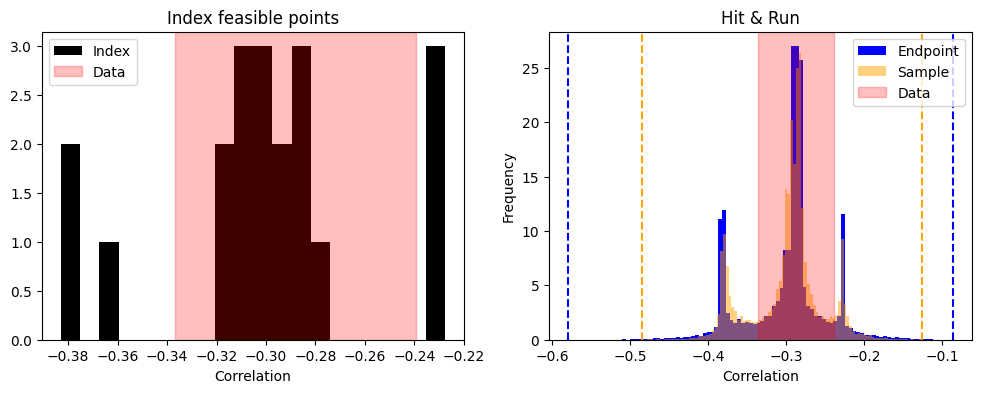

In [199]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].hist(corr_feas, bins=len(corr_feas), color="black", label="Index")
axs[0].axvspan(interval[0], interval[1], alpha=0.25, color="red", label="Data")
axs[0].set_title("Index feasible points")
axs[0].set_xlabel("Correlation")
axs[0].legend()
axs[1].hist(correlations_endpoint, color="blue", bins=100, density=True, label="Endpoint")
axs[1].axvline(min(correlations_endpoint), linestyle="--", color="blue")
axs[1].axvline(max(correlations_endpoint), linestyle="--", color="blue")
axs[1].hist(correlations_sample, color="orange", bins=100, alpha=0.5, density=True, label="Sample")
axs[1].axvline(min(correlations_sample), linestyle="--", color="orange")
axs[1].axvline(max(correlations_sample), linestyle="--", color="orange")
axs[1].axvspan(interval[0], interval[1], alpha=0.25, color="red", label="Data")
axs[1].set_title("Hit & Run")
axs[1].set_xlabel("Correlation")
axs[1].set_ylabel("Frequency")
axs[1].legend()
plt.show()

In [200]:
# settings
d_bd = 3
d_sd = 3
d = max(d_bd, d_sd)

# random feasible points
Nr = 100
y_feas_list = MOSEK_feasible_points(OB_bounds, beta, d_bd, d_sd, method="random", N=Nr)

# correlation
corr_feas = []
for y_feas in y_feas_list:
    corr_feas.append(MOSEK_compute_feasible_correlation(d, y_feas))

# hit and run methods: match size (endpoint 2 per, sample M per)
N = 2000
M = 10
Ne = N // 2
Ns = N // M
correlations_endpoint = []
correlations_sample = []
err_end, eps_end, err_sam, eps_sam = 0, 0, 0, 0
for y_feas in tqdm.tqdm(y_feas_list):
    corr, err, eps = hit_and_run(OB_bounds, beta, d_bd, d_sd, y_feas, N=Ne, method="endpoint")
    correlations_endpoint += corr
    err_end += err
    eps_end += eps
    corr, err, eps = hit_and_run(OB_bounds, beta, d_bd, d_sd, y_feas, N=Ns, method="sample", M=M)
    correlations_sample += corr
    err_sam += err
    eps_sam += eps

100%|██████████| 100/100 [01:19<00:00,  1.26it/s]


In [201]:
# most t intervals have t_min > 0 or t_max < 0 (~95,000 / 100,000)
# many have too small t intervals (~19,000 / 1000,000)
# likely due to feasible points being on the boundary
err_end, eps_end, err_sam, eps_sam

(98000, 96583, 19600, 19330)

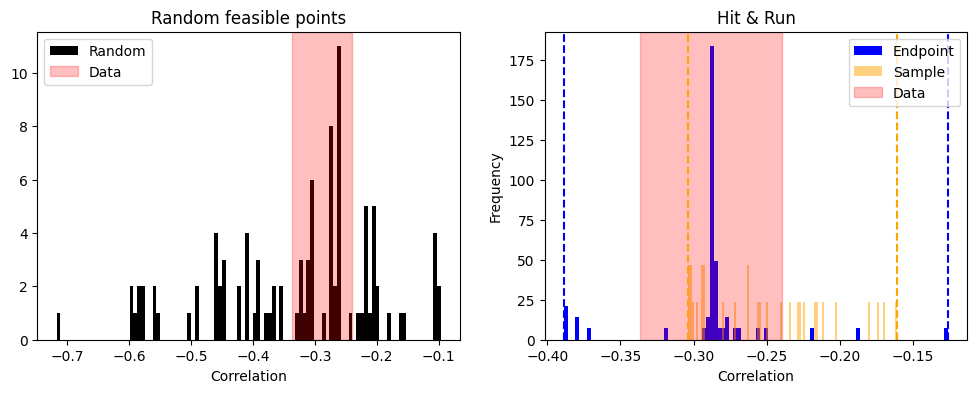

In [202]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].hist(corr_feas, bins=len(corr_feas), color="black", label="Random")
axs[0].axvspan(interval[0], interval[1], alpha=0.25, color="red", label="Data")
axs[0].set_title("Random feasible points")
axs[0].set_xlabel("Correlation")
axs[0].legend()
axs[1].hist(correlations_endpoint, color="blue", bins=100, density=True, label="Endpoint")
axs[1].axvline(min(correlations_endpoint), linestyle="--", color="blue")
axs[1].axvline(max(correlations_endpoint), linestyle="--", color="blue")
axs[1].hist(correlations_sample, color="orange", bins=100, alpha=0.5, density=True, label="Sample")
axs[1].axvline(min(correlations_sample), linestyle="--", color="orange")
axs[1].axvline(max(correlations_sample), linestyle="--", color="orange")
axs[1].axvspan(interval[0], interval[1], alpha=0.25, color="red", label="Data")
axs[1].set_title("Hit & Run")
axs[1].set_xlabel("Correlation")
axs[1].set_ylabel("Frequency")
axs[1].legend()
plt.show()

# Hit and Run

- start with initial feasible point y0
- sample random direction v
- compute t range s.t. y0 + tv feasible
- sample uniformly from t range to get point y1
- repeat process

Obtain set of feasible points {yi}

In [27]:
def hit_and_run_random(OB_bounds, beta, d_bd, d_sd, y_feas, N=1000, eps=10**-6):

    # compute the highest order moment required
    d = max(d_bd, d_sd)

    # helpful values
    S = 2
    U = []
    Nd = compute_Nd(S, d)
    Nbd = compute_Nd(S, d_bd)
    y_lb = OB_bounds[0, :Nbd]
    y_ub = OB_bounds[1, :Nbd]
    B = compute_B(beta, S, U, d_bd)

    # record feasible points
    y_feas_list = [y_feas]

    # record correlations
    correlations = [MOSEK_compute_feasible_correlation(d, y_feas)]

    # record numerical errors: err (tmin > 0 or tmax < 0), eps (|tmin - tmax| < eps)
    t_int_err = 0
    t_int_eps = 0

    # repeats
    for n in tqdm.tqdm(range(N - 1)):

        # get current feasible point
        y_feas = y_feas_list[-1]

        # sample random direction (uniform on sphere)
        v = rng.multivariate_normal(np.zeros(Nd), np.diag(np.ones(Nd)))
        v = v / np.linalg.norm(v)

        # ignore 1st dimension as fixed y[0] = 1
        v[0] = 0

        # linear t range: y_lb < B (y_0 + tv) < l_ub
        t_linear = np.zeros((Nd, 2))
        t_linear[0, :] = [-np.inf, np.inf]
        #t_linear_M = np.zeros((Nd, 2))
        #t_linear_M[0, :] = [-np.inf, np.inf]
        l = y_lb - B @ y_feas
        u = y_ub - B @ y_feas
        Bv = B @ v
        # l < t Bv < u
        for i in range(1, Nd):
            if Bv[i] > 0:
                t_linear[i, :] = [l[i] / Bv[i], u[i] / Bv[i]]
            else:
                t_linear[i, :] = [u[i] / Bv[i], l[i] / Bv[i]]

        #t_linear_M[1:, 0] = l[1:] / Bv[1:]
        #t_linear_M[1:, 1] = u[1:] / Bv[1:]
        #t_linear_M.sort(axis=1)

        #print(t_linear)
        #print(t_linear_M)

        # semidefinite t range
        t_semi = np.zeros((S + 1, 2))

        # for each matrix
        for s in range(S + 1):

            # select feasible point
            y_feas = y_feas_list[-1]

            # generalized eigenvalues
            C = compute_M_s_value(y_feas, s, S, d)
            D = compute_M_s_value(v, s, S, d)
            evals, _ = scipy.linalg.eig(C, -D)
            mu = np.array([np.real(ev) for ev in evals])

            # mu > 0 (lam < 0)
            mu_pos = mu[mu > 0]
            if mu_pos.size == 0:
                t_semi[s, 0] = -np.inf
            else:
                t_semi[s, 0] = -1 / np.max(mu_pos)

            # mu < 0 (lam > 0)
            mu_neg = mu[mu < 0]
            if mu_neg.size == 0:
                t_semi[s, 1] = np.inf
            else:
                t_semi[s, 1] = -1 / np.min(mu_neg)

        # intersect all t intervals
        t_min = max(np.max(t_linear[:, 0]), np.max(t_semi[:, 0]))
        t_max = min(np.min(t_linear[:, 1]), np.min(t_semi[:, 1]))

        # if width of t interval too small / numerical error: skip
        if (t_min > 0 or t_max < 0) and np.abs(t_max - t_min) < eps:
            t_int_err += 1
            t_int_eps += 1
            continue
        elif (t_min > 0 or t_max < 0):
            t_int_err += 1
            continue
        elif np.abs(t_max - t_min) < eps:
            t_int_eps += 1
            continue

        # uniformly sample feasible point along t line
        ts = rng.uniform(t_min, t_max)
        y_feas_new = y_feas + ts * v

        # store
        y_feas_list.append(y_feas_new)
        correlations.append(MOSEK_compute_feasible_correlation(d, y_feas_new))

    return correlations, t_int_err, t_int_eps

In [28]:
def hit_and_run_random_change(OB_bounds, beta, d_bd, d_sd, y_feas, N=1000, eps=10**-6):

    # compute the highest order moment required
    d = max(d_bd, d_sd)

    # helpful values
    S = 2
    U = []
    Nd = compute_Nd(S, d)
    Nbd = compute_Nd(S, d_bd)
    y_lb = OB_bounds[0, :Nbd]
    y_ub = OB_bounds[1, :Nbd]
    B = compute_B(beta, S, U, d_bd)

    # record feasible points
    y_feas_list = [y_feas]

    # record correlations
    correlations = [MOSEK_compute_feasible_correlation(d, y_feas)]

    # record numerical errors: err (tmin > 0 or tmax < 0), eps (|tmin - tmax| < eps)
    t_int_err = 0
    t_int_eps = 0

    # repeats
    for n in tqdm.tqdm(range(N - 1)):

        # get current feasible point
        y_feas = y_feas_list[-1]

        # sample random direction (uniform on sphere)
        v = rng.multivariate_normal(np.zeros(Nd), np.diag(np.ones(Nd)))
        v = v / np.linalg.norm(v)

        # ignore 1st dimension as fixed y[0] = 1
        v[0] = 0

        # linear t range: y_lb < B (y_0 + tv) < l_ub
        t_linear = np.zeros((Nd, 2))
        t_linear[0, :] = [-np.inf, np.inf]
        #t_linear_M = np.zeros((Nd, 2))
        #t_linear_M[0, :] = [-np.inf, np.inf]
        l = y_lb - B @ y_feas
        u = y_ub - B @ y_feas
        Bv = B @ v
        # l < t Bv < u
        for i in range(1, Nd):
            if Bv[i] > 0:
                t_linear[i, :] = [l[i] / Bv[i], u[i] / Bv[i]]
            else:
                t_linear[i, :] = [u[i] / Bv[i], l[i] / Bv[i]]

        #t_linear_M[1:, 0] = l[1:] / Bv[1:]
        #t_linear_M[1:, 1] = u[1:] / Bv[1:]
        #t_linear_M.sort(axis=1)

        #print(t_linear)
        #print(t_linear_M)

        # semidefinite t range
        t_semi = np.zeros((S + 1, 2))

        # for each matrix
        for s in range(S + 1):

            # select feasible point
            y_feas = y_feas_list[-1]

            # generalized eigenvalues
            C = compute_M_s_value(y_feas, s, S, d)
            D = compute_M_s_value(v, s, S, d)
            evals, _ = scipy.linalg.eig(C, -D)
            lam = np.array([np.real(ev) for ev in evals])

            # lam < 0
            lam_neg = lam[lam < 0]
            if lam_neg.size == 0:
                t_semi[s, 0] = -np.inf
            else:
                t_semi[s, 0] = np.max(lam_neg)
            
            # lam > 0
            lam_pos = lam[lam > 0]
            if lam_pos.size == 0:
                t_semi[s, 1] = np.inf
            else:
                t_semi[s, 1] = np.min(lam_pos)

        # intersect all t intervals
        t_min = max(np.max(t_linear[:, 0]), np.max(t_semi[:, 0]))
        t_max = min(np.min(t_linear[:, 1]), np.min(t_semi[:, 1]))

        # if width of t interval too small / numerical error: skip
        if (t_min > 0 or t_max < 0) and np.abs(t_max - t_min) < eps:
            t_int_err += 1
            t_int_eps += 1
            continue
        elif (t_min > 0 or t_max < 0):
            t_int_err += 1
            continue
        elif np.abs(t_max - t_min) < eps:
            t_int_eps += 1
            continue

        # uniformly sample feasible point along t line
        ts = rng.uniform(t_min, t_max)
        y_feas_new = y_feas + ts * v

        # store
        y_feas_list.append(y_feas_new)
        correlations.append(MOSEK_compute_feasible_correlation(d, y_feas_new))

    return correlations, t_int_err, t_int_eps

### Single feasible point

In [267]:
# settings
d_bd = 3
d_sd = 3
d = max(d_bd, d_sd)

# single feasible point
y_feas = MOSEK_feasible_points(OB_bounds, beta, d_bd, d_sd, method="single")

# correlation
corr_feas = MOSEK_compute_feasible_correlation(d, y_feas)
print(corr_feas)

# hit and run: random
Ns = [1000, 10000, 20000]
correlations = []
errs = []
epss = []
for N in Ns:
    correlations_random, err_rnd, eps_rnd = hit_and_run_random_change(OB_bounds, beta, d_bd, d_sd, y_feas, N=N)
    correlations.append(correlations_random)
    errs.append(err_rnd)
    epss.append(eps_rnd)

-0.29903314476141885


100%|██████████| 19999/19999 [00:13<00:00, 1526.63it/s]


In [268]:
# no t intervals have errors
errs, epss

([0, 0, 0], [0, 0, 0])

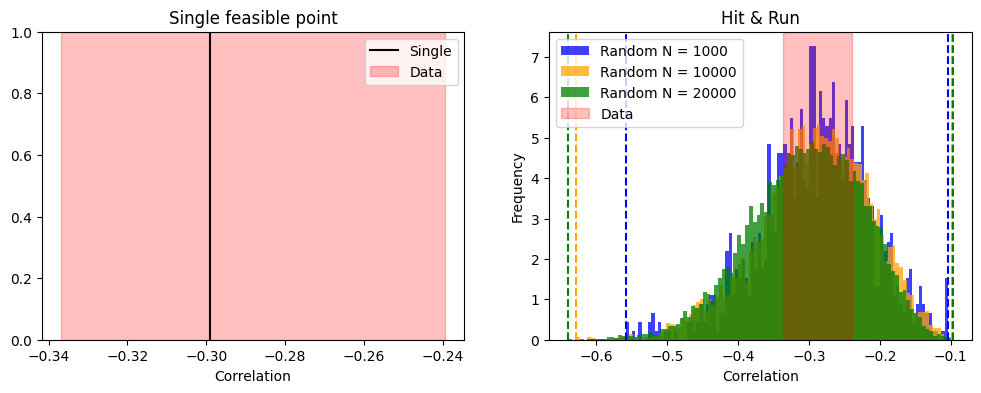

In [269]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].axvline(corr_feas, color="black", label="Single")
axs[0].axvspan(interval[0], interval[1], alpha=0.25, color="red", label="Data")
axs[0].set_title("Single feasible point")
axs[0].set_xlabel("Correlation")
axs[0].legend()
colours = ["blue", "orange", "green"]
for i, correlations_random in enumerate(correlations):
    axs[1].hist(correlations_random, color=colours[i], bins=100, density=True, label=f"Random N = {Ns[i]}", alpha=0.75)
    axs[1].axvline(min(correlations_random), linestyle="--", color=colours[i])
    axs[1].axvline(max(correlations_random), linestyle="--", color=colours[i])
axs[1].axvspan(interval[0], interval[1], alpha=0.25, color="red", label="Data")
axs[1].set_title("Hit & Run")
axs[1].set_xlabel("Correlation")
axs[1].set_ylabel("Frequency")
axs[1].legend()
plt.show()

### Random objective feasible points

In [270]:
# settings
d_bd = 3
d_sd = 3
d = max(d_bd, d_sd)

# random feasible points
Nr = 10
y_feas_list = MOSEK_feasible_points(OB_bounds, beta, d_bd, d_sd, method="random", N=Nr)

# correlation
corr_feas = []
for y_feas in y_feas_list:
    corr_feas.append(MOSEK_compute_feasible_correlation(d, y_feas))

# hit and run methods: match size (endpoint 2 per, sample M per)
N = 10000
correlations_random = []
err_rnd, eps_rnd = 0, 0
for y_feas in tqdm.tqdm(y_feas_list):
    corr, err, eps = hit_and_run_random_change(OB_bounds, beta, d_bd, d_sd, y_feas, N=N)
    correlations_random += corr
    err_rnd += err
    eps_rnd += eps

100%|██████████| 10/10 [01:03<00:00,  6.32s/it]


In [271]:
# many t intervals have issues when using boundary points from random objectives
err_rnd, eps_rnd

(99990, 96885)

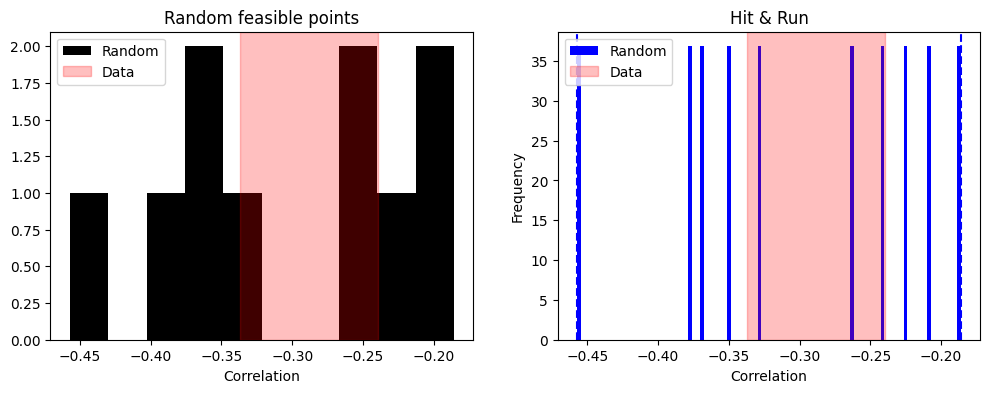

In [272]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].hist(corr_feas, bins=len(corr_feas), color="black", label="Random")
axs[0].axvspan(interval[0], interval[1], alpha=0.25, color="red", label="Data")
axs[0].set_title("Random feasible points")
axs[0].set_xlabel("Correlation")
axs[0].legend()
axs[1].hist(correlations_random, color="blue", bins=100, density=True, label="Random")
axs[1].axvline(min(correlations_random), linestyle="--", color="blue")
axs[1].axvline(max(correlations_random), linestyle="--", color="blue")
axs[1].axvspan(interval[0], interval[1], alpha=0.25, color="red", label="Data")
axs[1].set_title("Hit & Run")
axs[1].set_xlabel("Correlation")
axs[1].set_ylabel("Frequency")
axs[1].legend()
plt.show()

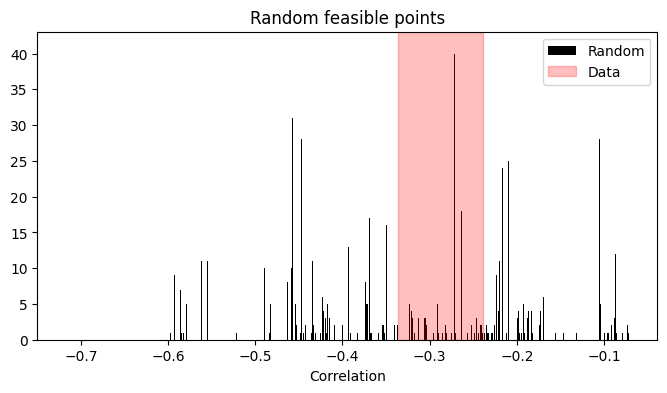

In [284]:
# settings
d_bd = 3
d_sd = 3
d = max(d_bd, d_sd)

# random feasible points
Nr = 1000
y_feas_list = MOSEK_feasible_points(OB_bounds, beta, d_bd, d_sd, method="random", N=Nr)

# correlation
corr_feas = []
for y_feas in y_feas_list:
    corr_feas.append(MOSEK_compute_feasible_correlation(d, y_feas))

fig, axs = plt.subplots(1, 1, figsize=(8, 4))
axs.hist(corr_feas, bins=len(corr_feas), color="black", label="Random")
axs.axvspan(interval[0], interval[1], alpha=0.25, color="red", label="Data")
axs.set_title("Random feasible points")
axs.set_xlabel("Correlation")
axs.legend()

### Random Coordinate sampling

Rather than sampling a random direction from the sphere, instead sample a random direction to move along

In [29]:
def hit_and_run_random_coordinate(OB_bounds, beta, d_bd, d_sd, y_feas, N=1000, eps=10**-6):

    # compute the highest order moment required
    d = max(d_bd, d_sd)

    # helpful values
    S = 2
    U = []
    Nd = compute_Nd(S, d)
    Nbd = compute_Nd(S, d_bd)
    y_lb = OB_bounds[0, :Nbd]
    y_ub = OB_bounds[1, :Nbd]
    B = compute_B(beta, S, U, d_bd)

    # record feasible points
    y_feas_list = [y_feas]

    # record correlations
    correlations = [MOSEK_compute_feasible_correlation(d, y_feas)]

    # record numerical errors: err (tmin > 0 or tmax < 0), eps (|tmin - tmax| < eps)
    t_int_err = 0
    t_int_eps = 0

    # repeats
    for n in tqdm.tqdm(range(N - 1)):

        # get current feasible point
        y_feas = y_feas_list[-1]

        # sample random coordinate: except 1st dimension as fixed y[0] = 1
        vi = rng.integers(1, Nd)
        v = np.zeros(Nd)
        v[vi] = 1

        # linear t range: y_lb < B (y_0 + tv) < l_ub
        t_linear = np.zeros((Nd, 2))
        t_linear[0, :] = [-np.inf, np.inf]
        #t_linear_M = np.zeros((Nd, 2))
        #t_linear_M[0, :] = [-np.inf, np.inf]
        l = y_lb - B @ y_feas
        u = y_ub - B @ y_feas
        Bv = B @ v
        # l < t Bv < u
        for i in range(1, Nd):
            if Bv[i] > 0:
                t_linear[i, :] = [l[i] / Bv[i], u[i] / Bv[i]]
            elif Bv[i] < 0:
                t_linear[i, :] = [u[i] / Bv[i], l[i] / Bv[i]]
            else:
                t_linear[i, :] = [-np.inf, np.inf]

        #t_linear_M[1:, 0] = l[1:] / Bv[1:]
        #t_linear_M[1:, 1] = u[1:] / Bv[1:]
        #t_linear_M.sort(axis=1)

        #print(t_linear)
        #print(t_linear_M)

        # semidefinite t range
        t_semi = np.zeros((S + 1, 2))

        # for each matrix
        for s in range(S + 1):

            # select feasible point
            y_feas = y_feas_list[-1]

            # generalized eigenvalues
            C = compute_M_s_value(y_feas, s, S, d)
            D = compute_M_s_value(v, s, S, d)
            evals, _ = scipy.linalg.eig(C, -D)
            mu = np.array([np.real(ev) for ev in evals])

            # mu > 0 (lam < 0)
            mu_pos = mu[mu > 0]
            if mu_pos.size == 0:
                t_semi[s, 0] = -np.inf
            else:
                t_semi[s, 0] = -1 / np.max(mu_pos)

            # mu < 0 (lam > 0)
            mu_neg = mu[mu < 0]
            if mu_neg.size == 0:
                t_semi[s, 1] = np.inf
            else:
                t_semi[s, 1] = -1 / np.min(mu_neg)

        # intersect all t intervals
        t_min = max(np.max(t_linear[:, 0]), np.max(t_semi[:, 0]))
        t_max = min(np.min(t_linear[:, 1]), np.min(t_semi[:, 1]))

        # if width of t interval too small / numerical error: skip
        if (t_min > 0 or t_max < 0) and np.abs(t_max - t_min) < eps:
            t_int_err += 1
            t_int_eps += 1
            continue
        elif (t_min > 0 or t_max < 0):
            t_int_err += 1
            continue
        elif np.abs(t_max - t_min) < eps:
            t_int_eps += 1
            continue

        # uniformly sample feasible point along t line
        ts = rng.uniform(t_min, t_max)
        y_feas_new = y_feas + ts * v

        # store
        y_feas_list.append(y_feas_new)
        correlations.append(MOSEK_compute_feasible_correlation(d, y_feas_new))

    return correlations, t_int_err, t_int_eps

In [30]:
def hit_and_run_random_coordinate_change(OB_bounds, beta, d_bd, d_sd, y_feas, N=1000, eps=10**-6):

    # compute the highest order moment required
    d = max(d_bd, d_sd)

    # helpful values
    S = 2
    U = []
    Nd = compute_Nd(S, d)
    Nbd = compute_Nd(S, d_bd)
    y_lb = OB_bounds[0, :Nbd]
    y_ub = OB_bounds[1, :Nbd]
    B = compute_B(beta, S, U, d_bd)

    # record feasible points
    y_feas_list = [y_feas]

    # record correlations
    correlations = [MOSEK_compute_feasible_correlation(d, y_feas)]

    # record numerical errors: err (tmin > 0 or tmax < 0), eps (|tmin - tmax| < eps)
    t_int_err = 0
    t_int_eps = 0

    # repeats
    for n in tqdm.tqdm(range(N - 1)):

        # get current feasible point
        y_feas = y_feas_list[-1]

        # sample random coordinate: except 1st dimension as fixed y[0] = 1
        vi = rng.integers(1, Nd)
        v = np.zeros(Nd)
        v[vi] = 1

        # linear t range: y_lb < B (y_0 + tv) < l_ub
        t_linear = np.zeros((Nd, 2))
        t_linear[0, :] = [-np.inf, np.inf]
        #t_linear_M = np.zeros((Nd, 2))
        #t_linear_M[0, :] = [-np.inf, np.inf]
        l = y_lb - B @ y_feas
        u = y_ub - B @ y_feas
        Bv = B @ v
        # l < t Bv < u
        for i in range(1, Nd):
            if Bv[i] > 0:
                t_linear[i, :] = [l[i] / Bv[i], u[i] / Bv[i]]
            elif Bv[i] < 0:
                t_linear[i, :] = [u[i] / Bv[i], l[i] / Bv[i]]
            else:
                t_linear[i, :] = [-np.inf, np.inf]

        #t_linear_M[1:, 0] = l[1:] / Bv[1:]
        #t_linear_M[1:, 1] = u[1:] / Bv[1:]
        #t_linear_M.sort(axis=1)

        #print(t_linear)
        #print(t_linear_M)

        # semidefinite t range
        t_semi = np.zeros((S + 1, 2))

        # for each matrix
        for s in range(S + 1):

            # select feasible point
            y_feas = y_feas_list[-1]

            # generalized eigenvalues
            C = compute_M_s_value(y_feas, s, S, d)
            D = compute_M_s_value(v, s, S, d)
            evals, _ = scipy.linalg.eig(C, -D)
            lam = np.array([np.real(ev) for ev in evals])

            # lam < 0
            lam_neg = lam[lam < 0]
            if lam_neg.size == 0:
                t_semi[s, 0] = -np.inf
            else:
                t_semi[s, 0] = np.max(lam_neg)
            
            # lam > 0
            lam_pos = lam[lam > 0]
            if lam_pos.size == 0:
                t_semi[s, 1] = np.inf
            else:
                t_semi[s, 1] = np.min(lam_pos)

        # intersect all t intervals
        t_min = max(np.max(t_linear[:, 0]), np.max(t_semi[:, 0]))
        t_max = min(np.min(t_linear[:, 1]), np.min(t_semi[:, 1]))

        # if width of t interval too small / numerical error: skip
        if (t_min > 0 or t_max < 0) and np.abs(t_max - t_min) < eps:
            t_int_err += 1
            t_int_eps += 1
            continue
        elif (t_min > 0 or t_max < 0):
            t_int_err += 1
            continue
        elif np.abs(t_max - t_min) < eps:
            t_int_eps += 1
            continue

        # uniformly sample feasible point along t line
        ts = rng.uniform(t_min, t_max)
        y_feas_new = y_feas + ts * v

        # store
        y_feas_list.append(y_feas_new)
        correlations.append(MOSEK_compute_feasible_correlation(d, y_feas_new))

    return correlations, t_int_err, t_int_eps

In [277]:
# settings
d_bd = 3
d_sd = 3
d = max(d_bd, d_sd)

# single feasible point
y_feas = MOSEK_feasible_points(OB_bounds, beta, d_bd, d_sd, method="single")

# correlation
corr_feas = MOSEK_compute_feasible_correlation(d, y_feas)
print(corr_feas)

# hit and run: random
Ns = [1000, 10000, 20000]
correlations = []
errs = []
epss = []
for N in Ns:
    correlations_random, err_rnd, eps_rnd = hit_and_run_random_coordinate_change(OB_bounds, beta, d_bd, d_sd, y_feas, N=N)
    correlations.append(correlations_random)
    errs.append(err_rnd)
    epss.append(eps_rnd)

-0.29903314476141885


100%|██████████| 19999/19999 [00:10<00:00, 1875.68it/s]


In [278]:
errs, epss

([0, 0, 0], [0, 0, 0])

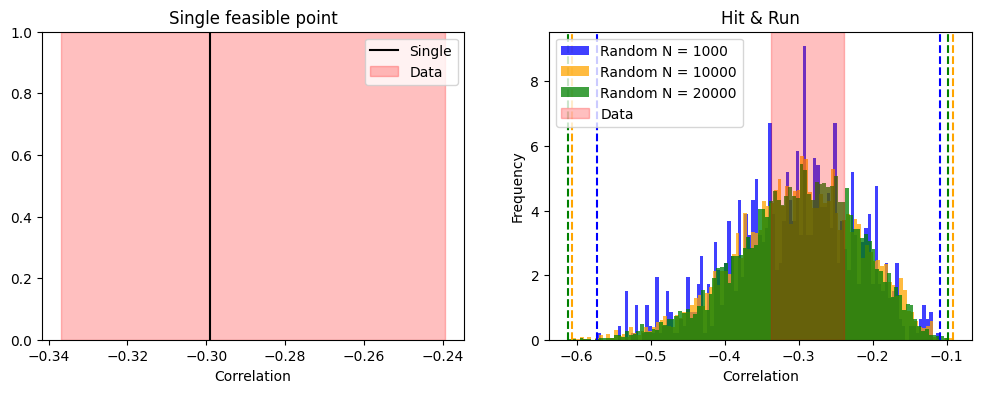

In [279]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].axvline(corr_feas, color="black", label="Single")
axs[0].axvspan(interval[0], interval[1], alpha=0.25, color="red", label="Data")
axs[0].set_title("Single feasible point")
axs[0].set_xlabel("Correlation")
axs[0].legend()
colours = ["blue", "orange", "green"]
for i, correlations_random in enumerate(correlations):
    axs[1].hist(correlations_random, color=colours[i], bins=100, density=True, label=f"Random N = {Ns[i]}", alpha=0.75)
    axs[1].axvline(min(correlations_random), linestyle="--", color=colours[i])
    axs[1].axvline(max(correlations_random), linestyle="--", color=colours[i])
axs[1].axvspan(interval[0], interval[1], alpha=0.25, color="red", label="Data")
axs[1].set_title("Hit & Run")
axs[1].set_xlabel("Correlation")
axs[1].set_ylabel("Frequency")
axs[1].legend()
plt.show()

### (ACHR) Artificial centering hit and run

Sample random directions for a number of steps as warmup, then use feasible points found to inform future directions to try to address issues with different scales of different variables

In [31]:
def hit_and_run_ACHR(OB_bounds, beta, d_bd, d_sd, y_feas, N=1000, eps=10**-6, warmup=10):

    # compute the highest order moment required
    d = max(d_bd, d_sd)

    # helpful values
    S = 2
    U = []
    Nd = compute_Nd(S, d)
    Nbd = compute_Nd(S, d_bd)
    y_lb = OB_bounds[0, :Nbd]
    y_ub = OB_bounds[1, :Nbd]
    B = compute_B(beta, S, U, d_bd)

    # record feasible points
    y_feas_list = [y_feas]

    # record correlations
    correlations = [MOSEK_compute_feasible_correlation(d, y_feas)]

    # store center
    center = y_feas

    # record numerical errors: err (tmin > 0 or tmax < 0), eps (|tmin - tmax| < eps)
    t_int_err = 0
    t_int_eps = 0

    # repeats
    for n in tqdm.tqdm(range(1, N)):

        # get current feasible point
        y_feas = y_feas_list[-1]

        # within warmup
        if n < warmup:

            # sample random direction (uniform on sphere)
            v = rng.multivariate_normal(np.zeros(Nd), np.diag(np.ones(Nd)))
            v = v / np.linalg.norm(v)

        # outside warmup
        else:

            # sample index
            i = rng.integers(n)

            # set direction as from center to ith point
            v = y_feas_list[i] - center
            v = v / np.linalg.norm(v)

        # ignore 1st dimension as fixed y[0] = 1
        v[0] = 0

        # linear t range: y_lb < B (y_0 + tv) < l_ub
        t_linear = np.zeros((Nd, 2))
        t_linear[0, :] = [-np.inf, np.inf]
        #t_linear_M = np.zeros((Nd, 2))
        #t_linear_M[0, :] = [-np.inf, np.inf]
        l = y_lb - B @ y_feas
        u = y_ub - B @ y_feas
        Bv = B @ v
        # l < t Bv < u
        for i in range(1, Nd):
            if Bv[i] > 0:
                t_linear[i, :] = [l[i] / Bv[i], u[i] / Bv[i]]
            else:
                t_linear[i, :] = [u[i] / Bv[i], l[i] / Bv[i]]

        #t_linear_M[1:, 0] = l[1:] / Bv[1:]
        #t_linear_M[1:, 1] = u[1:] / Bv[1:]
        #t_linear_M.sort(axis=1)

        #print(t_linear)
        #print(t_linear_M)

        # semidefinite t range
        t_semi = np.zeros((S + 1, 2))

        # for each matrix
        for s in range(S + 1):

            # select feasible point
            y_feas = y_feas_list[-1]

            # generalized eigenvalues
            C = compute_M_s_value(y_feas, s, S, d)
            D = compute_M_s_value(v, s, S, d)
            evals, _ = scipy.linalg.eig(C, -D)
            lam = np.array([np.real(ev) for ev in evals])

            # lam < 0
            lam_neg = lam[lam < 0]
            if lam_neg.size == 0:
                t_semi[s, 0] = -np.inf
            else:
                t_semi[s, 0] = np.max(lam_neg)
            
            # lam > 0
            lam_pos = lam[lam > 0]
            if lam_pos.size == 0:
                t_semi[s, 1] = np.inf
            else:
                t_semi[s, 1] = np.min(lam_pos)

        # intersect all t intervals
        t_min = max(np.max(t_linear[:, 0]), np.max(t_semi[:, 0]))
        t_max = min(np.min(t_linear[:, 1]), np.min(t_semi[:, 1]))

        # if width of t interval too small / numerical error: skip
        if (t_min > 0 or t_max < 0) and np.abs(t_max - t_min) < eps:
            t_int_err += 1
            t_int_eps += 1
            continue
        elif (t_min > 0 or t_max < 0):
            t_int_err += 1
            continue
        elif np.abs(t_max - t_min) < eps:
            t_int_eps += 1
            continue

        # uniformly sample feasible point along t line
        ts = rng.uniform(t_min, t_max)
        y_feas_new = y_feas + ts * v

        # store
        y_feas_list.append(y_feas_new)
        correlations.append(MOSEK_compute_feasible_correlation(d, y_feas_new))

        # update center
        center = (n * center + y_feas_new) / (n + 1)

    return correlations, t_int_err, t_int_eps

In [286]:
# settings
d_bd = 3
d_sd = 3
d = max(d_bd, d_sd)

# single feasible point
y_feas = MOSEK_feasible_points(OB_bounds, beta, d_bd, d_sd, method="single")

# correlation
corr_feas = MOSEK_compute_feasible_correlation(d, y_feas)
print(corr_feas)

# hit and run: random
Ns = [1000, 10000, 20000]
correlations = []
errs = []
epss = []
for N in Ns:
    correlations_AHCR, err_AHCR, eps_AHCR = hit_and_run_ACHR(OB_bounds, beta, d_bd, d_sd, y_feas, N=N, warmup=10)
    correlations.append(correlations_AHCR)
    errs.append(err_AHCR)
    epss.append(eps_AHCR)

-0.29903314476141885


100%|██████████| 19999/19999 [00:12<00:00, 1570.68it/s]


In [287]:
errs, epss

([0, 0, 0], [0, 0, 0])

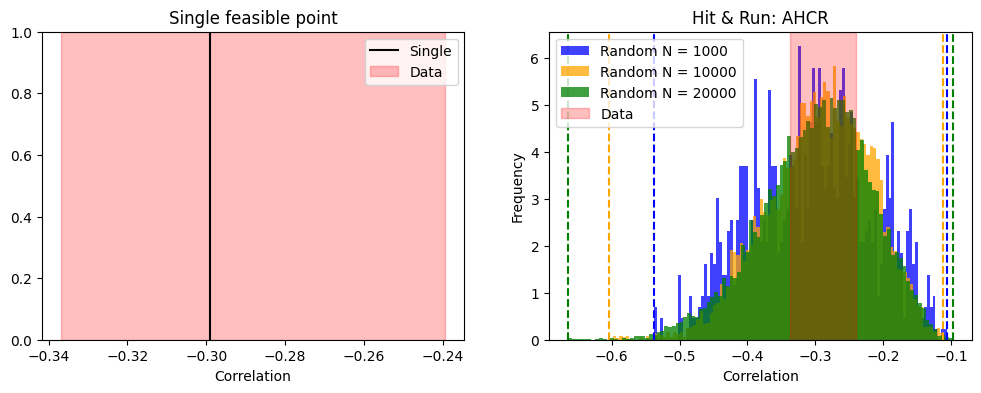

In [288]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].axvline(corr_feas, color="black", label="Single")
axs[0].axvspan(interval[0], interval[1], alpha=0.25, color="red", label="Data")
axs[0].set_title("Single feasible point")
axs[0].set_xlabel("Correlation")
axs[0].legend()
colours = ["blue", "orange", "green"]
for i, correlations_AHCR in enumerate(correlations):
    axs[1].hist(correlations_AHCR, color=colours[i], bins=100, density=True, label=f"Random N = {Ns[i]}", alpha=0.75)
    axs[1].axvline(min(correlations_AHCR), linestyle="--", color=colours[i])
    axs[1].axvline(max(correlations_AHCR), linestyle="--", color=colours[i])
axs[1].axvspan(interval[0], interval[1], alpha=0.25, color="red", label="Data")
axs[1].set_title("Hit & Run: AHCR")
axs[1].set_xlabel("Correlation")
axs[1].set_ylabel("Frequency")
axs[1].legend()
plt.show()

# Updated test

In [44]:
def MOSEK_compute_feasible_correlation(d, y):
    '''Compute correlation value at feasible point.'''

    S = 2

    # find indices of moments
    powers = compute_powers(S, d)
    i_xy = powers.index([1, 1])
    i_x  = powers.index([1, 0])
    i_y  = powers.index([0, 1])
    i_x2 = powers.index([2, 0])
    i_y2 = powers.index([0, 2])

    # collect moment values
    E_xy = y[i_xy]
    E_x  = y[i_x]
    E_y  = y[i_y]
    E_x2 = y[i_x2]
    E_y2 = y[i_y2]

    # compute correlation
    correlation = (E_xy - E_x*E_y) / (np.sqrt(E_x2 - E_x**2) * np.sqrt(E_y2 - E_y**2))

    return float(correlation)

In [33]:
def MOSEK_feasible_points(OB_bounds, beta, d_bd, d_sd, method="single", N=100):

    # compute the highest order moment required
    d = max(d_bd, d_sd)

    # helpful values
    S = 2
    U = []
    Nd = compute_Nd(S, d)
    Nbd = compute_Nd(S, d_bd)

    with Model('MOSEK-SDP') as md: 

        # variables
        y = md.variable('y', Nd, Domain.greaterThan(0.))

        # variable dict
        variables = {
            'y': y
        }

        # moment matrices
        for s in range(S + 1):

            # restrict to d_sd
            M_s = MOSEK_construct_M_s(y, s, S, d_sd)
            variables[f'M_{s}'] = M_s

            # PSD
            md.constraint(f'M_{s}_PSD', M_s == Domain.inPSDCone())

        # moment bounds

        # get CI bounds on OB moments (up to order d_bd)
        y_lb = OB_bounds[0, :Nbd]
        y_ub = OB_bounds[1, :Nbd]

        # B scaling matrix
        B = compute_B(beta, S, U, d_bd)

        # moment bounds
        md.constraint('y_UB', B @ y[:Nbd] <= y_ub)
        md.constraint('y_LB', B @ y[:Nbd] >= y_lb)

        # fixed moment
        md.constraint('y0', y[0] == 1)

        # find feasible point(s)
        if method == "single":

            # single feasible point
            md.objective(0)
            md.solve()
            y_feas = y.level()

        elif method == "index":

            # feasible point for min and max of each variable (index of y)
            y_feas = []
            for i in range(Nd):
                
                # minimize
                try:
                    md.objective(ObjectiveSense.Minimize, y[i])
                    md.solve()
                    y_feas.append(y.level())
                except SolutionError:
                    print("SE")
                    pass

                # maximize
                try:
                    md.objective(ObjectiveSense.Maximize, y[i])
                    md.solve()
                    y_feas.append(y.level())
                except SolutionError:
                    print("SE")
                    pass

        elif method == "random":

            # optimize random linear objectives
            y_feas = []

            for i in range(N):
                try:
                    c = np.zeros(Nd)
                    c[:Nbd] = rng.uniform(-1, 1, size=Nbd)
                    md.objective(ObjectiveSense.Minimize, y.T @ c)
                    md.solve()
                    y_feas.append(y.level())
                except SolutionError:
                    print("SE")
                    pass
        
        elif obj == "random_2":

            # optimize random linear objectives: only including order <2 moments
            y_feas = []

            N2 = compute_Nd(2, 2)
            for i in range(N):
                try:
                    c = np.zeros(Nd)
                    c[:N2] = rng.uniform(-1, 1, size=N2) # only optimize over moments in correlation function
                    md.objective(ObjectiveSense.Minimize, y.T @ c)
                    md.solve()
                    y_feas.append(y.level())
                except SolutionError:
                    print("SE")
                    pass

    return y_feas

In [83]:
def hit_and_run(OB_bounds, beta, d_bd, d_sd, y_feas, N=1000, eps=10**-6):

    # compute the highest order moment required
    d = max(d_bd, d_sd)

    # helpful values
    S = 2
    U = []
    Nd = compute_Nd(S, d)
    Nbd = compute_Nd(S, d_bd)
    y_lb = OB_bounds[0, :Nbd]
    y_ub = OB_bounds[1, :Nbd]
    B = compute_B(beta, S, U, d_bd)

    # record feasible points
    y_feas_list = [y_feas]

    # record correlations
    correlations = [MOSEK_compute_feasible_correlation(d, y_feas)]

    # record numerical errors: err (tmin > 0 or tmax < 0), eps (|tmin - tmax| < eps)
    t_int_err = 0
    t_int_eps = 0

    # repeats
    for n in tqdm.tqdm(range(N - 1)):

        # get current feasible point
        y_feas = y_feas_list[-1]

        # sample random direction (uniform on sphere)
        v = rng.multivariate_normal(np.zeros(Nd), np.diag(np.ones(Nd)))
        v = v / np.linalg.norm(v)

        # ignore 1st dimension as fixed y[0] = 1
        v[0] = 0

        # linear t range: y_lb < B (y_0 + tv) < l_ub
        t_linear = np.zeros((Nd, 2))
        t_linear[0, :] = [-np.inf, np.inf]
        #t_linear_M = np.zeros((Nd, 2))
        #t_linear_M[0, :] = [-np.inf, np.inf]
        l = y_lb - B @ y_feas
        u = y_ub - B @ y_feas
        Bv = B @ v
        # l < t Bv < u
        for i in range(1, Nd):
            if Bv[i] > 0:
                t_linear[i, :] = [l[i] / Bv[i], u[i] / Bv[i]]
            elif Bv[i] < 0:
                t_linear[i, :] = [u[i] / Bv[i], l[i] / Bv[i]]
            else:
                t_linear[i, :] = [-np.inf, np.inf]

        #t_linear_M[1:, 0] = l[1:] / Bv[1:]
        #t_linear_M[1:, 1] = u[1:] / Bv[1:]
        #t_linear_M.sort(axis=1)

        #print(t_linear)
        #print(t_linear_M)

        # semidefinite t range
        t_semi = np.zeros((S + 1, 2))

        # for each matrix
        for s in range(S + 1):

            # select feasible point
            y_feas = y_feas_list[-1]

            # generalized eigenvalues
            C = compute_M_s_value(y_feas, s, S, d)
            D = compute_M_s_value(v, s, S, d)
            evals, _ = scipy.linalg.eig(C, -D)
            lam = np.array([np.real(ev) for ev in evals])

            # lam < 0
            lam_neg = lam[lam < 0]
            if lam_neg.size == 0:
                t_semi[s, 0] = -np.inf
            else:
                t_semi[s, 0] = np.max(lam_neg)
            
            # lam > 0
            lam_pos = lam[lam > 0]
            if lam_pos.size == 0:
                t_semi[s, 1] = np.inf
            else:
                t_semi[s, 1] = np.min(lam_pos)

        # intersect all t intervals
        t_min = max(np.max(t_linear[:, 0]), np.max(t_semi[:, 0]))
        t_max = min(np.min(t_linear[:, 1]), np.min(t_semi[:, 1]))

        # if width of t interval too small / numerical error: skip
        if (t_min > 0 or t_max < 0) and np.abs(t_max - t_min) < eps:
            t_int_err += 1
            t_int_eps += 1
            continue
        elif (t_min > 0 or t_max < 0):
            t_int_err += 1
            continue
        elif np.abs(t_max - t_min) < eps:
            t_int_eps += 1
            continue

        # uniformly sample feasible point along t line
        ts = rng.uniform(t_min, t_max)
        y_feas_new = y_feas + ts * v

        # store
        y_feas_list.append(y_feas_new)
        correlations.append(MOSEK_compute_feasible_correlation(d, y_feas_new))

    return correlations, t_int_err, t_int_eps

In [35]:
def hit_and_run_coordinate(OB_bounds, beta, d_bd, d_sd, y_feas, N=1000, eps=10**-6):

    # compute the highest order moment required
    d = max(d_bd, d_sd)

    # helpful values
    S = 2
    U = []
    Nd = compute_Nd(S, d)
    Nbd = compute_Nd(S, d_bd)
    y_lb = OB_bounds[0, :Nbd]
    y_ub = OB_bounds[1, :Nbd]
    B = compute_B(beta, S, U, d_bd)

    # record feasible points
    y_feas_list = [y_feas]

    # record correlations
    correlations = [MOSEK_compute_feasible_correlation(d, y_feas)]

    # record numerical errors: err (tmin > 0 or tmax < 0), eps (|tmin - tmax| < eps)
    t_int_err = 0
    t_int_eps = 0

    # repeats
    for n in tqdm.tqdm(range(N - 1)):

        # get current feasible point
        y_feas = y_feas_list[-1]

        # sample random coordinate: except 1st dimension as fixed y[0] = 1
        vi = rng.integers(1, Nd)
        v = np.zeros(Nd)
        v[vi] = 1

        # linear t range: y_lb < B (y_0 + tv) < l_ub
        t_linear = np.zeros((Nd, 2))
        t_linear[0, :] = [-np.inf, np.inf]
        #t_linear_M = np.zeros((Nd, 2))
        #t_linear_M[0, :] = [-np.inf, np.inf]
        l = y_lb - B @ y_feas
        u = y_ub - B @ y_feas
        Bv = B @ v
        # l < t Bv < u
        for i in range(1, Nd):
            if Bv[i] > 0:
                t_linear[i, :] = [l[i] / Bv[i], u[i] / Bv[i]]
            elif Bv[i] < 0:
                t_linear[i, :] = [u[i] / Bv[i], l[i] / Bv[i]]
            else:
                t_linear[i, :] = [-np.inf, np.inf]

        #t_linear_M[1:, 0] = l[1:] / Bv[1:]
        #t_linear_M[1:, 1] = u[1:] / Bv[1:]
        #t_linear_M.sort(axis=1)

        #print(t_linear)
        #print(t_linear_M)

        # semidefinite t range
        t_semi = np.zeros((S + 1, 2))

        # for each matrix
        for s in range(S + 1):

            # select feasible point
            y_feas = y_feas_list[-1]

            # generalized eigenvalues
            C = compute_M_s_value(y_feas, s, S, d)
            D = compute_M_s_value(v, s, S, d)
            evals, _ = scipy.linalg.eig(C, -D)
            lam = np.array([np.real(ev) for ev in evals])

            # lam < 0
            lam_neg = lam[lam < 0]
            if lam_neg.size == 0:
                t_semi[s, 0] = -np.inf
            else:
                t_semi[s, 0] = np.max(lam_neg)
            
            # lam > 0
            lam_pos = lam[lam > 0]
            if lam_pos.size == 0:
                t_semi[s, 1] = np.inf
            else:
                t_semi[s, 1] = np.min(lam_pos)

        # intersect all t intervals
        t_min = max(np.max(t_linear[:, 0]), np.max(t_semi[:, 0]))
        t_max = min(np.min(t_linear[:, 1]), np.min(t_semi[:, 1]))

        # if width of t interval too small / numerical error: skip
        if (t_min > 0 or t_max < 0) and np.abs(t_max - t_min) < eps:
            t_int_err += 1
            t_int_eps += 1
            continue
        elif (t_min > 0 or t_max < 0):
            t_int_err += 1
            continue
        elif np.abs(t_max - t_min) < eps:
            t_int_eps += 1
            continue

        # uniformly sample feasible point along t line
        ts = rng.uniform(t_min, t_max)
        y_feas_new = y_feas + ts * v

        # store
        y_feas_list.append(y_feas_new)
        correlations.append(MOSEK_compute_feasible_correlation(d, y_feas_new))

    return correlations, t_int_err, t_int_eps

In [84]:
def hit_and_run_ACHR(OB_bounds, beta, d_bd, d_sd, y_feas, N=1000, eps=10**-6, warmup=10):

    # compute the highest order moment required
    d = max(d_bd, d_sd)

    # helpful values
    S = 2
    U = []
    Nd = compute_Nd(S, d)
    Nbd = compute_Nd(S, d_bd)
    y_lb = OB_bounds[0, :Nbd]
    y_ub = OB_bounds[1, :Nbd]
    B = compute_B(beta, S, U, d_bd)

    # record feasible points
    y_feas_list = [y_feas]

    # record correlations
    correlations = [MOSEK_compute_feasible_correlation(d, y_feas)]

    # store center
    center = y_feas

    # record numerical errors: err (tmin > 0 or tmax < 0), eps (|tmin - tmax| < eps)
    t_int_err = 0
    t_int_eps = 0

    # repeats
    for n in tqdm.tqdm(range(1, N)):

        # get current feasible point
        y_feas = y_feas_list[-1]

        # within warmup
        if n < warmup:

            # sample random direction (uniform on sphere)
            v = rng.multivariate_normal(np.zeros(Nd), np.diag(np.ones(Nd)))
            v = v / np.linalg.norm(v)

        # outside warmup
        else:

            # sample index
            i = rng.integers(n)

            # set direction as from center to ith point
            v = y_feas_list[i] - center
            v = v / np.linalg.norm(v)

        # ignore 1st dimension as fixed y[0] = 1
        v[0] = 0

        # linear t range: y_lb < B (y_0 + tv) < l_ub
        t_linear = np.zeros((Nd, 2))
        t_linear[0, :] = [-np.inf, np.inf]
        #t_linear_M = np.zeros((Nd, 2))
        #t_linear_M[0, :] = [-np.inf, np.inf]
        l = y_lb - B @ y_feas
        u = y_ub - B @ y_feas
        Bv = B @ v
        # l < t Bv < u
        for i in range(1, Nd):
            if Bv[i] > 0:
                t_linear[i, :] = [l[i] / Bv[i], u[i] / Bv[i]]
            elif Bv[i] < 0:
                t_linear[i, :] = [u[i] / Bv[i], l[i] / Bv[i]]
            else:
                t_linear[:, i] = [-np.inf, np.inf]

        #t_linear_M[1:, 0] = l[1:] / Bv[1:]
        #t_linear_M[1:, 1] = u[1:] / Bv[1:]
        #t_linear_M.sort(axis=1)

        #print(t_linear)
        #print(t_linear_M)

        # semidefinite t range
        t_semi = np.zeros((S + 1, 2))

        # for each matrix
        for s in range(S + 1):

            # select feasible point
            y_feas = y_feas_list[-1]

            # generalized eigenvalues
            C = compute_M_s_value(y_feas, s, S, d)
            D = compute_M_s_value(v, s, S, d)
            evals, _ = scipy.linalg.eig(C, -D)
            lam = np.array([np.real(ev) for ev in evals])

            # lam < 0
            lam_neg = lam[lam < 0]
            if lam_neg.size == 0:
                t_semi[s, 0] = -np.inf
            else:
                t_semi[s, 0] = np.max(lam_neg)
            
            # lam > 0
            lam_pos = lam[lam > 0]
            if lam_pos.size == 0:
                t_semi[s, 1] = np.inf
            else:
                t_semi[s, 1] = np.min(lam_pos)

        # intersect all t intervals
        t_min = max(np.max(t_linear[:, 0]), np.max(t_semi[:, 0]))
        t_max = min(np.min(t_linear[:, 1]), np.min(t_semi[:, 1]))

        # if width of t interval too small / numerical error: skip
        if (t_min > 0 or t_max < 0) and np.abs(t_max - t_min) < eps:
            t_int_err += 1
            t_int_eps += 1
            continue
        elif (t_min > 0 or t_max < 0):
            t_int_err += 1
            continue
        elif np.abs(t_max - t_min) < eps:
            t_int_eps += 1
            continue

        # uniformly sample feasible point along t line
        ts = rng.uniform(t_min, t_max)
        y_feas_new = y_feas + ts * v

        # store
        y_feas_list.append(y_feas_new)
        correlations.append(MOSEK_compute_feasible_correlation(d, y_feas_new))

        # update center
        center = (n * center + y_feas_new) / (n + 1)

    return correlations, t_int_err, t_int_eps

In [37]:
def txt_int(correlation):
    mn = round(min(correlation), 2)
    mx = round(max(correlation), 2)
    return f"({mn}, {mx})"

In [38]:
def plot_corr_hist(axs, correlations, color, name, bins=None, alpha=1):
    axs.hist(correlations, density=True, color=color, label=f"{name} {txt_int(correlations)}", bins=bins, alpha=alpha)
    axs.axvline(min(correlations), color=color, linestyle="--")
    axs.axvline(max(correlations), color=color, linestyle="--")

In [39]:
def plot_data_interval(axs, interval, color="red", name="Data CI"):
    axs.axvspan(interval[0], interval[1], alpha=0.25, color=color, label=f"{name} {txt_int(interval)}")

In [294]:
# settings
k_tx = 2
k_deg = 1
k_reg = 1

n = 1000
N = 1000

# sample
params = {
    'k_tx_1': k_tx,
    'k_tx_2': k_tx,
    'k_deg_1': k_deg,
    'k_deg_2': k_deg,
    'k_reg': k_reg
}
sample = gillespie_birth_death(params, n)

# downsample
mean_capture = 1
downsample, beta = downsample_data(sample, mean_capture)

# mean expression level
print(f"Mean expression {np.mean(downsample)}")

# order
d_boot = 6

# bootstrap
OB_bounds = bootstrap(downsample, d_boot, N)

# data correlation
interval = data_correlation_bootstrap(np.array(sample))

Mean expression 1.121
Correlation statistic -0.2679908073686559 
95% Confidence Interval (-0.32278141563390034, -0.2150505945760084)


### Method comparison: Standard H&R, coordinate, ACHR

In [299]:
# settings
d = 3
N = 1000

# single feasible point
y_feas = MOSEK_feasible_points(OB_bounds, beta, d, d, method="single")

# correlation
corr_feas = MOSEK_compute_feasible_correlation(d, y_feas)

# hit and run
correlations, err, eps = hit_and_run(OB_bounds, beta, d, d, y_feas, N=N)

# coordinate
correlations_CHR, err_CHR, eps_CHR = hit_and_run_coordinate(OB_bounds, beta, d, d, y_feas, N=N)

# AHCR
correlations_ACHR, err_ACHR, eps_ACHR = hit_and_run_ACHR(OB_bounds, beta, d, d, y_feas, N=N)

100%|██████████| 999/999 [00:00<00:00, 1877.10it/s]


In [303]:
([err, err_CHR, err_AHCR], [eps, eps_CHR, eps_AHCR])

([0, 0, 0], [0, 0, 0])

Text(0.5, 0.98, 'Hit and Run Method Comparison')

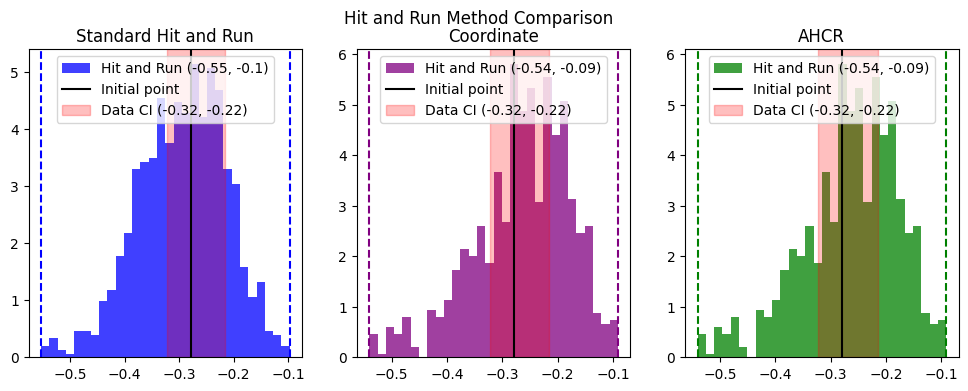

In [302]:
fig, axs = plt.subplots(1, 3, figsize=(12, 4), squeeze=False)
plot_corr_hist(axs[0, 0], correlations, "blue", "Hit and Run", bins=30, alpha=0.75)
axs[0, 0].axvline(corr_feas, color="black", label="Initial point")
plot_data_interval(axs[0, 0], interval)
axs[0, 0].set_title("Standard Hit and Run")
axs[0, 0].legend()
plot_corr_hist(axs[0, 1], correlations_CHR, "purple", "Hit and Run", bins=30, alpha=0.75)
axs[0, 1].axvline(corr_feas, color="black", label="Initial point")
plot_data_interval(axs[0, 1], interval)
axs[0, 1].set_title("Coordinate")
axs[0, 1].legend()
plot_corr_hist(axs[0, 2], correlations_CHR, "green", "Hit and Run", bins=30, alpha=0.75)
axs[0, 2].axvline(corr_feas, color="black", label="Initial point")
plot_data_interval(axs[0, 2], interval)
axs[0, 2].set_title("AHCR")
axs[0, 2].legend()
fig.suptitle("Hit and Run Method Comparison")

### Effect of N

In [308]:
# settings
d = 3

# single feasible point
y_feas = MOSEK_feasible_points(OB_bounds, beta, d, d, method="single")

# correlation
corr_feas = MOSEK_compute_feasible_correlation(d, y_feas)

# hit and run: random
Ns = [1000, 5000, 10000]
correlations_list = []
errs = []
epss = []
for N in Ns:
    correlations, err, eps = hit_and_run(OB_bounds, beta, d, d, y_feas, N=N)
    correlations_list.append(correlations)
    errs.append(err)
    epss.append(eps)

100%|██████████| 9999/9999 [00:06<00:00, 1498.80it/s]


In [309]:
errs, epss

([0, 0, 0], [0, 0, 0])

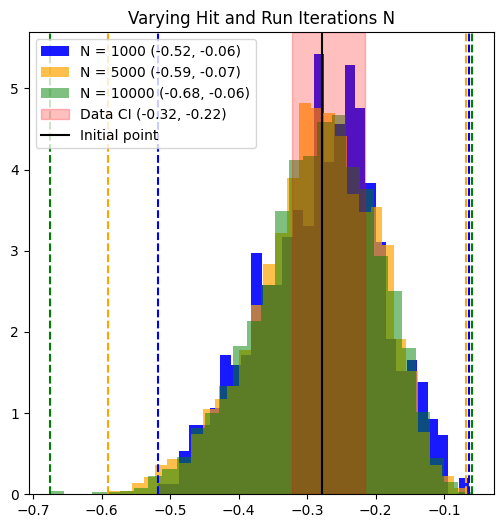

In [311]:
fig, axs = plt.subplots(1, 1, figsize=(6, 6), squeeze=False)
colors = ["blue", "orange", "green"]
alphas = [0.9, 0.7, 0.5]
for i, N in enumerate(Ns):
    plot_corr_hist(axs[0, 0], correlations_list[i], colors[i], f"N = {N}", bins=30, alpha=alphas[i])
plot_data_interval(axs[0, 0], interval)
axs[0, 0].axvline(corr_feas, color="black", label="Initial point")
axs[0, 0].set_title("Varying Hit and Run Iterations N")
axs[0, 0].legend()

### Dependence on initial point

In [40]:
def hit_and_run_points(OB_bounds, beta, d_bd, d_sd, y_feas, N=1000, eps=10**-6):

    # compute the highest order moment required
    d = max(d_bd, d_sd)

    # helpful values
    S = 2
    U = []
    Nd = compute_Nd(S, d)
    Nbd = compute_Nd(S, d_bd)
    y_lb = OB_bounds[0, :Nbd]
    y_ub = OB_bounds[1, :Nbd]
    B = compute_B(beta, S, U, d_bd)

    # record feasible points
    y_feas_list = [y_feas]

    # record correlations
    correlations = [MOSEK_compute_feasible_correlation(d, y_feas)]

    # record numerical errors: err (tmin > 0 or tmax < 0), eps (|tmin - tmax| < eps)
    t_int_err = 0
    t_int_eps = 0

    # repeats
    for n in tqdm.tqdm(range(N - 1)):

        # get current feasible point
        y_feas = y_feas_list[-1]

        # sample random direction (uniform on sphere)
        v = rng.multivariate_normal(np.zeros(Nd), np.diag(np.ones(Nd)))
        v = v / np.linalg.norm(v)

        # ignore 1st dimension as fixed y[0] = 1
        v[0] = 0

        # linear t range: y_lb < B (y_0 + tv) < l_ub
        t_linear = np.zeros((Nd, 2))
        t_linear[0, :] = [-np.inf, np.inf]
        #t_linear_M = np.zeros((Nd, 2))
        #t_linear_M[0, :] = [-np.inf, np.inf]
        l = y_lb - B @ y_feas
        u = y_ub - B @ y_feas
        Bv = B @ v
        # l < t Bv < u
        for i in range(1, Nd):
            if Bv[i] > 0:
                t_linear[i, :] = [l[i] / Bv[i], u[i] / Bv[i]]
            else:
                t_linear[i, :] = [u[i] / Bv[i], l[i] / Bv[i]]

        #t_linear_M[1:, 0] = l[1:] / Bv[1:]
        #t_linear_M[1:, 1] = u[1:] / Bv[1:]
        #t_linear_M.sort(axis=1)

        #print(t_linear)
        #print(t_linear_M)

        # semidefinite t range
        t_semi = np.zeros((S + 1, 2))

        # for each matrix
        for s in range(S + 1):

            # select feasible point
            y_feas = y_feas_list[-1]

            # generalized eigenvalues
            C = compute_M_s_value(y_feas, s, S, d)
            D = compute_M_s_value(v, s, S, d)
            evals, _ = scipy.linalg.eig(C, -D)
            lam = np.array([np.real(ev) for ev in evals])

            # lam < 0
            lam_neg = lam[lam < 0]
            if lam_neg.size == 0:
                t_semi[s, 0] = -np.inf
            else:
                t_semi[s, 0] = np.max(lam_neg)
            
            # lam > 0
            lam_pos = lam[lam > 0]
            if lam_pos.size == 0:
                t_semi[s, 1] = np.inf
            else:
                t_semi[s, 1] = np.min(lam_pos)

        # intersect all t intervals
        t_min = max(np.max(t_linear[:, 0]), np.max(t_semi[:, 0]))
        t_max = min(np.min(t_linear[:, 1]), np.min(t_semi[:, 1]))

        # if width of t interval too small / numerical error: skip
        if (t_min > 0 or t_max < 0) and np.abs(t_max - t_min) < eps:
            t_int_err += 1
            t_int_eps += 1
            continue
        elif (t_min > 0 or t_max < 0):
            t_int_err += 1
            continue
        elif np.abs(t_max - t_min) < eps:
            t_int_eps += 1
            continue

        # uniformly sample feasible point along t line
        ts = rng.uniform(t_min, t_max)
        y_feas_new = y_feas + ts * v

        # store
        y_feas_list.append(y_feas_new)
        correlations.append(MOSEK_compute_feasible_correlation(d, y_feas_new))

    return correlations, y_feas_list

In [411]:
# settings
d = 3
N = 1000

# single feasible point
y_feas = MOSEK_feasible_points(OB_bounds, beta, d, d, method="single")

# correlation
corr_feas = MOSEK_compute_feasible_correlation(d, y_feas)

# hit and run
correlations, y_feas = hit_and_run_points(OB_bounds, beta, d, d, y_feas, N=N)

# get most extreme correlation point
min_idx = correlations.index(min(correlations))
y_ext = y_feas[min_idx]
corr_ext = correlations[min_idx]

# hit and run with this tail starting point
correlations_ext, err, eps = hit_and_run(OB_bounds, beta, d, d, y_ext, N=N)

100%|██████████| 999/999 [00:00<00:00, 1354.15it/s]


In [412]:
err, eps

(0, 0)

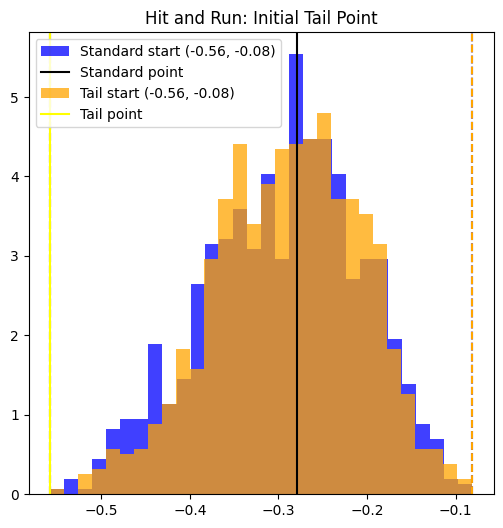

In [413]:
fig, axs = plt.subplots(1, 1, figsize=(6, 6), squeeze=False)
plot_corr_hist(axs[0, 0], correlations, "blue", "Standard start", bins=30, alpha=0.75)
axs[0, 0].axvline(corr_feas, color="black", label="Standard point")
plot_corr_hist(axs[0, 0], correlations_ext, "orange", "Tail start", bins=30, alpha=0.75)
axs[0, 0].axvline(corr_ext, color="yellow", label="Tail point")
#plot_data_interval(axs[0, 0], interval)
axs[0, 0].set_title("Hit and Run: Initial Tail Point")
axs[0, 0].legend()

### Confidence level

In [414]:
# settings
k_tx = 2
k_deg = 1
k_reg = 1

n = 1000
N = 1000

# sample
params = {
    'k_tx_1': k_tx,
    'k_tx_2': k_tx,
    'k_deg_1': k_deg,
    'k_deg_2': k_deg,
    'k_reg': k_reg
}
sample = gillespie_birth_death(params, n)

# downsample
mean_capture = 1
downsample, beta = downsample_data(sample, mean_capture)

# mean expression level
print(f"Mean expression {np.mean(downsample)}")

# order
d_boot = 6

# bootstrap
OB_bounds = bootstrap(downsample, d_boot, N)
OB_bounds_50 = bootstrap(downsample, d_boot, N, confidence=0.5)

# data correlation
interval = data_correlation_bootstrap(np.array(sample))
interval_50 = data_correlation_bootstrap(np.array(sample), confidence=0.5)

Mean expression 1.126
Correlation statistic -0.2900575070851004 
95% Confidence Interval (-0.3377871491923638, -0.24065049310045036)
Correlation statistic -0.2900575070851004 
50% Confidence Interval (-0.3080353888952548, -0.274130821600791)


100%|██████████| 999/999 [00:00<00:00, 1381.97it/s]


Text(0.5, 0.98, 'Effect of confidence level')

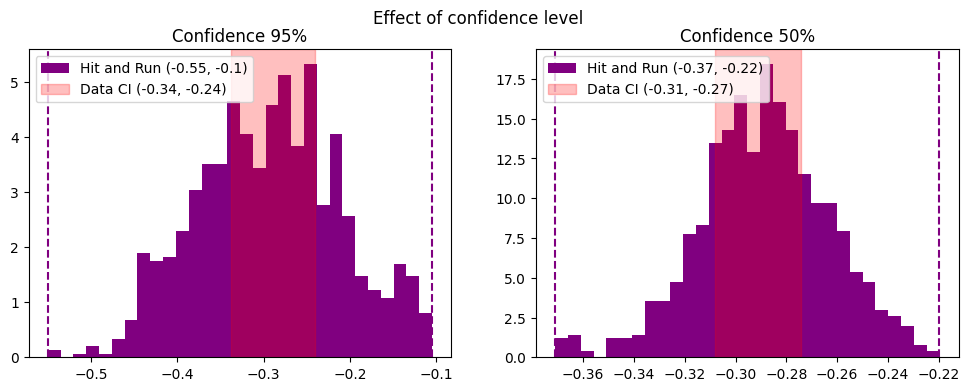

In [416]:
# settings
d = 3

# 95% confidence
y_feas_95 = MOSEK_feasible_points(OB_bounds, beta, d, d, method="single")
y_corr_95, err_95, eps_95 = hit_and_run(OB_bounds, beta, d, d, y_feas_95, N=N)

# 50% confidence
y_feas_50 = MOSEK_feasible_points(OB_bounds_50, beta, d, d, method="single")
y_corr_50, err_50, eps_50 = hit_and_run(OB_bounds_50, beta, d, d, y_feas_50, N=N)

fig, axs = plt.subplots(1, 2, figsize=(12, 4), squeeze=False)
plot_corr_hist(axs[0, 0], y_corr_95, "purple", "Hit and Run", bins=30)
plot_data_interval(axs[0, 0], interval)
axs[0, 0].set_title("Confidence 95%")
axs[0, 0].legend()
plot_corr_hist(axs[0, 1], y_corr_50, "purple", "Hit and Run", bins=30)
plot_data_interval(axs[0, 1], interval_50)
axs[0, 1].set_title("Confidence 50%")
axs[0, 1].legend()
fig.suptitle("Effect of confidence level")

In [418]:
([err_95, err_50], [eps_95, eps_50])

([0, 0], [0, 0])

### Data simulated with capture efficiency

In [417]:
# settings
k_tx = 2
k_deg = 1
k_reg = 1

n = 1000
N = 1000

# sample
params = {
    'k_tx_1': k_tx,
    'k_tx_2': k_tx,
    'k_deg_1': k_deg,
    'k_deg_2': k_deg,
    'k_reg': k_reg
}
sample = gillespie_birth_death(params, n)

# downsample
mean_capture = 0.5
downsample, beta = downsample_data(sample, mean_capture)

# mean expression level
print(f"Mean expression {np.mean(downsample)}")

# order
d_boot = 6

# bootstrap
OB_bounds = bootstrap(downsample, d_boot, N, confidence=0.5)

# data correlation
interval_OG = data_correlation_bootstrap(np.array(sample), confidence=0.5)
interval_OB = data_correlation_bootstrap(np.array(downsample), confidence=0.5)

Mean expression 0.5405
Correlation statistic -0.29539278652373047 
50% Confidence Interval (-0.3119005740151721, -0.2813839590178581)
Correlation statistic -0.01984757060543138 
50% Confidence Interval (-0.03709878775372679, -0.0033247038074701897)


In [419]:
# settings
d = 3

# random
y_feas = MOSEK_feasible_points(OB_bounds, beta, d, d, method="single")
y_corr, err, eps = hit_and_run(OB_bounds, beta, d, d, y_feas, N=N)

100%|██████████| 999/999 [00:00<00:00, 1487.35it/s]


In [420]:
err, eps

(0, 0)

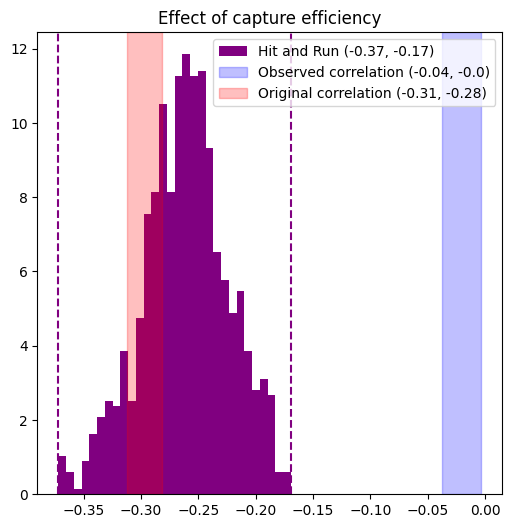

In [421]:
fig, axs = plt.subplots(1, 1, figsize=(6, 6), squeeze=False)
plot_corr_hist(axs[0, 0], y_corr, "purple", "Hit and Run", bins=30)
plot_data_interval(axs[0, 0], interval_OB, color="blue", name="Observed correlation")
plot_data_interval(axs[0, 0], interval_OG, color="red", name="Original correlation")
axs[0, 0].set_title("Effect of capture efficiency")
axs[0, 0].legend()

### Real data

In [422]:
# read fibroblast transcript counts
data_FIB = pd.read_csv("../../Real-Data-2/Data/GSE151334_FIB_counts_thresh.csv", index_col=0)

# load capture
beta = np.loadtxt("../../Real-Data-2/Capture/beta_FIB.txt")

# load RNA types
biotypes_dict = json.load(open("../../Real-Data-2/Biotypes/biotypes_FIB.json"))

# select indices of protein coding mRNA and non-coding miRNA
pcRNA_indices = [idx for idx, btype in enumerate(biotypes_dict.values()) if btype == "protein_coding"]
miRNA_indices = [idx for idx, btype in enumerate(biotypes_dict.values()) if btype == "miRNA"]

# separate data
data_FIB_pcRNA = data_FIB.iloc[pcRNA_indices]
data_FIB_miRNA = data_FIB.iloc[miRNA_indices]

In [423]:
# select
miRNA = "MIR100"
mRNA_idx = 1

# construct sample
sample_miRNA = data_FIB_miRNA.loc[miRNA]
sample_mRNA = data_FIB_pcRNA.iloc[mRNA_idx]
sample = list(zip(sample_miRNA, sample_mRNA))

# order
d_boot = 4

# bootstrap
OB_bounds = bootstrap(sample, d_boot, 1000, confidence=0.95)
OB_bounds_50 = bootstrap(sample, d_boot, 1000, confidence=0.5)

# data correlation
interval = data_correlation_bootstrap(np.array(sample), confidence=0.95)
interval_50 = data_correlation_bootstrap(np.array(sample), confidence=0.5)

Correlation statistic 0.06778759988545108 
95% Confidence Interval (-0.018847648251281157, 0.20642820334361625)
Correlation statistic 0.06778759988545108 
50% Confidence Interval (0.0326352563292936, 0.1160146271569748)


100%|██████████| 999/999 [00:00<00:00, 1325.37it/s]


Text(0.5, 0.98, 'Real Data')

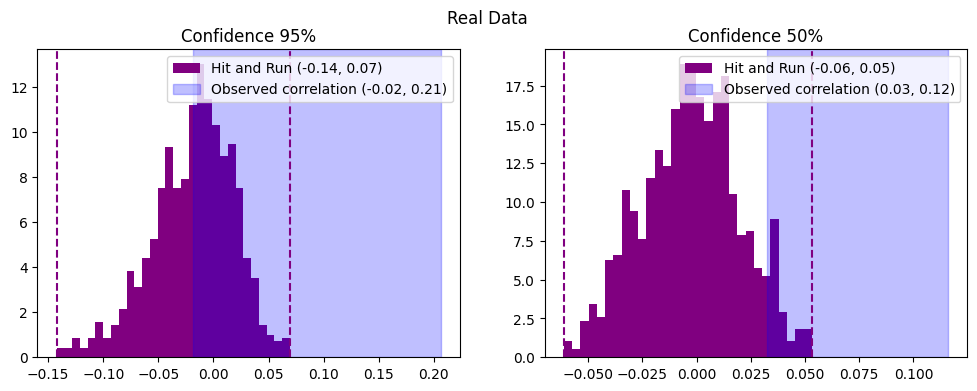

In [424]:
# settings
d = 3

# 95% confidence
y_feas_95 = MOSEK_feasible_points(OB_bounds, beta, d, d, method="single")
y_corr_95, err_95, eps_95 = hit_and_run(OB_bounds, beta, d, d, y_feas_95, N=N)

# 50% confidence
y_feas_50 = MOSEK_feasible_points(OB_bounds_50, beta, d, d, method="single")
y_corr_50, err_50, eps_50 = hit_and_run(OB_bounds_50, beta, d, d, y_feas_50, N=N)

fig, axs = plt.subplots(1, 2, figsize=(12, 4), squeeze=False)
plot_corr_hist(axs[0, 0], y_corr_95, "purple", "Hit and Run", bins=30)
plot_data_interval(axs[0, 0], interval, color="blue", name="Observed correlation")
axs[0, 0].set_title("Confidence 95%")
axs[0, 0].legend()
plot_corr_hist(axs[0, 1], y_corr_50, "purple", "Hit and Run", bins=30)
plot_data_interval(axs[0, 1], interval_50, color="blue", name="Observed correlation")
axs[0, 1].set_title("Confidence 50%")
axs[0, 1].legend()
fig.suptitle("Real Data")

### Method comparison: Higher order

In [85]:
# settings
k_tx = 2
k_deg = 1
k_reg = 1

n = 1000
N = 1000

# sample
params = {
    'k_tx_1': k_tx,
    'k_tx_2': k_tx,
    'k_deg_1': k_deg,
    'k_deg_2': k_deg,
    'k_reg': k_reg
}
sample = gillespie_birth_death(params, n)

# downsample
mean_capture = 1
downsample, beta = downsample_data(sample, mean_capture)

# mean expression level
print(f"Mean expression {np.mean(downsample)}")

# order
d_boot = 6

# bootstrap
OB_bounds = bootstrap(downsample, d_boot, N)

# data correlation
interval = data_correlation_bootstrap(np.array(sample))

Mean expression 1.107
Correlation statistic -0.27953520589171377 
95% Confidence Interval (-0.3269042479843019, -0.22804929786579667)


100%|██████████| 999/999 [00:01<00:00, 945.41it/s]


Text(0.5, 0.98, 'Hit and Run Method Comparison: Higher order')

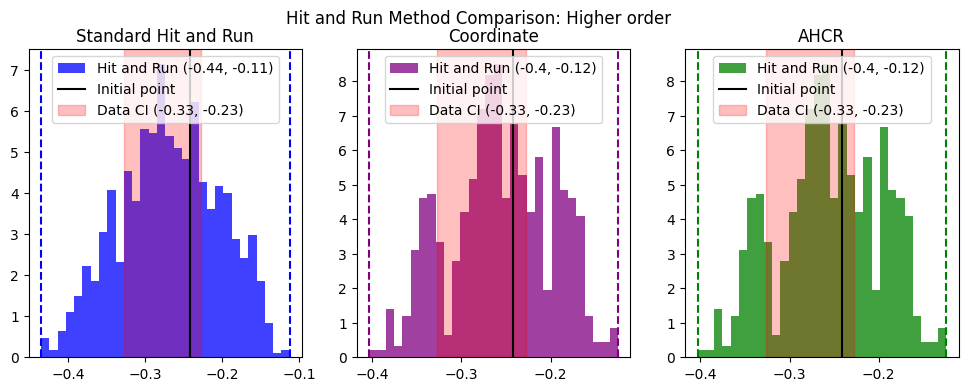

In [87]:
# settings
d = 5
N = 1000

# single feasible point
y_feas = MOSEK_feasible_points(OB_bounds, beta, d, d, method="single")

# correlation
corr_feas = MOSEK_compute_feasible_correlation(d, y_feas)

# hit and run
correlations, err, eps = hit_and_run(OB_bounds, beta, d, d, y_feas, N=N)

# coordinate
correlations_CHR, err_CHR, eps_CHR = hit_and_run_coordinate(OB_bounds, beta, d, d, y_feas, N=N)

# AHCR
correlations_ACHR, err_ACHR, eps_ACHR = hit_and_run_ACHR(OB_bounds, beta, d, d, y_feas, N=N)

# plot
fig, axs = plt.subplots(1, 3, figsize=(12, 4), squeeze=False)
plot_corr_hist(axs[0, 0], correlations, "blue", "Hit and Run", bins=30, alpha=0.75)
axs[0, 0].axvline(corr_feas, color="black", label="Initial point")
plot_data_interval(axs[0, 0], interval)
axs[0, 0].set_title("Standard Hit and Run")
axs[0, 0].legend()
plot_corr_hist(axs[0, 1], correlations_CHR, "purple", "Hit and Run", bins=30, alpha=0.75)
axs[0, 1].axvline(corr_feas, color="black", label="Initial point")
plot_data_interval(axs[0, 1], interval)
axs[0, 1].set_title("Coordinate")
axs[0, 1].legend()
plot_corr_hist(axs[0, 2], correlations_CHR, "green", "Hit and Run", bins=30, alpha=0.75)
axs[0, 2].axvline(corr_feas, color="black", label="Initial point")
plot_data_interval(axs[0, 2], interval)
axs[0, 2].set_title("AHCR")
axs[0, 2].legend()
fig.suptitle("Hit and Run Method Comparison: Higher order")

In [89]:
([err, err_CHR, err_ACHR], [eps, eps_CHR, eps_ACHR])

([0, 0, 0], [0, 0, 0])

### Method comparison: capture efficiency

In [90]:
# settings
k_tx = 2
k_deg = 1
k_reg = 1

n = 1000
N = 1000

# sample
params = {
    'k_tx_1': k_tx,
    'k_tx_2': k_tx,
    'k_deg_1': k_deg,
    'k_deg_2': k_deg,
    'k_reg': k_reg
}
sample = gillespie_birth_death(params, n)

# downsample
mean_capture = 0.25
downsample, beta = downsample_data(sample, mean_capture)

# mean expression level
print(f"Mean expression {np.mean(downsample)}")

# order
d_boot = 4

# bootstrap
OB_bounds = bootstrap(downsample, d_boot, N, confidence=0.5)

# data correlation
interval_OG = data_correlation_bootstrap(np.array(sample), confidence=0.5)
interval_OB = data_correlation_bootstrap(np.array(downsample), confidence=0.5)

Mean expression 0.273
Correlation statistic -0.26134782392988243 
50% Confidence Interval (-0.27836090625563226, -0.24484316169985815)
Correlation statistic 0.08748970719502638 
50% Confidence Interval (0.06801721270109459, 0.11034614672459032)


100%|██████████| 999/999 [00:00<00:00, 1713.49it/s]


Text(0.5, 0.98, 'Hit and Run Method Comparison: lower capture')

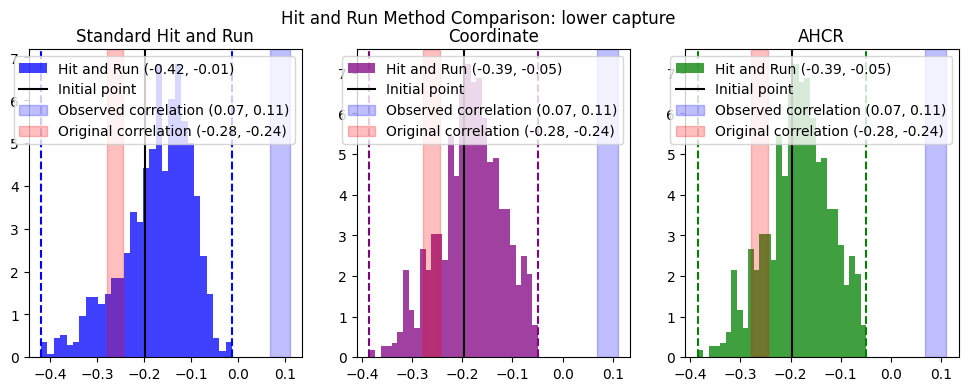

In [92]:
# settings
d = 3
N = 1000

# single feasible point
y_feas = MOSEK_feasible_points(OB_bounds, beta, d, d, method="single")

# correlation
corr_feas = MOSEK_compute_feasible_correlation(d, y_feas)

# hit and run
correlations, err, eps = hit_and_run(OB_bounds, beta, d, d, y_feas, N=N)

# coordinate
correlations_CHR, err_CHR, eps_CHR = hit_and_run_coordinate(OB_bounds, beta, d, d, y_feas, N=N)

# AHCR
correlations_ACHR, err_ACHR, eps_ACHR = hit_and_run_ACHR(OB_bounds, beta, d, d, y_feas, N=N)

# plot
fig, axs = plt.subplots(1, 3, figsize=(12, 4), squeeze=False)
plot_corr_hist(axs[0, 0], correlations, "blue", "Hit and Run", bins=30, alpha=0.75)
axs[0, 0].axvline(corr_feas, color="black", label="Initial point")
plot_data_interval(axs[0, 0], interval_OB, color="blue", name="Observed correlation")
plot_data_interval(axs[0, 0], interval_OG, color="red", name="Original correlation")
axs[0, 0].set_title("Standard Hit and Run")
axs[0, 0].legend()
plot_corr_hist(axs[0, 1], correlations_CHR, "purple", "Hit and Run", bins=30, alpha=0.75)
axs[0, 1].axvline(corr_feas, color="black", label="Initial point")
plot_data_interval(axs[0, 1], interval_OB, color="blue", name="Observed correlation")
plot_data_interval(axs[0, 1], interval_OG, color="red", name="Original correlation")
axs[0, 1].set_title("Coordinate")
axs[0, 1].legend()
plot_corr_hist(axs[0, 2], correlations_CHR, "green", "Hit and Run", bins=30, alpha=0.75)
axs[0, 2].axvline(corr_feas, color="black", label="Initial point")
plot_data_interval(axs[0, 2], interval_OB, color="blue", name="Observed correlation")
plot_data_interval(axs[0, 2], interval_OG, color="red", name="Original correlation")
axs[0, 2].set_title("AHCR")
axs[0, 2].legend()
fig.suptitle("Hit and Run Method Comparison: lower capture")

In [93]:
([err, err_CHR, err_ACHR], [eps, eps_CHR, eps_ACHR])

([0, 0, 0], [0, 0, 0])

# Summary

- Standard method, coordinates and AHCR all very similar
    - no clear difference even for higher order (when might be most anistropic)
    - standard method (sphere) may be slightly different for lower capture, but very minor
- Use interior point as H&R start
    - issues with numerics of t intervals when using boundary points e.g. from optimization
    - also gives many t intervals that are very small <10**-6 eps threshold, so would just accept many points that are close and so gives spike of same correlations
- Random linear objectives finds some feasible points with slightly more extreme values than H&R
    - Likely tail points that would be found with large enough N
    - Unclear to how significant